# Per-site de-trended `s` — **no-filter twin** of the production panel

Robustness check on the climate-graded SV purging pattern: the same per-site
$s - \text{same-}p_0\text{ SNP baseline}$ grid as Section 1 of `temporal_s_consolidated.ipynb`,
but with **every variant filter removed**.

| | production panel | this twin |
|---|---|---|
| founder panel | MAC ≥ 12, call-rate ≥ 0.9 | **dropped** |
| $p_0$ boundary | $0.02 \le p_0 \le 0.98$ | **dropped** (only finite $0<p_0<1$) |
| SV count | 4,946 | **226,468** (45×; 71.6% at $p_0<0.02$) |
| window | `max(51, n//8)` per class → SV 619 vs baseline 3125 | **fixed, matched across classes** |

**Why matched bandwidth.** In production the SV curve is smoothed with a 619-point window while
the SNP baseline it subtracts uses 3125 — a 5× mismatch, so the two curves estimate the local
median at different resolutions and the residual can carry smoothing bias. Here every class uses
the same window. (Applying the production `n//8` rule to 226k unfiltered SVs would give
win ≈ 28,000 and over-smooth far worse than the filtered version, so the rule is not reused.)

**`s`** = per-variant plot-replicate selection coefficient = mean over the site's replicate plots
of the OLS slope of $\mathrm{logit}(p)$ on generation (gen 0 = shared founding $p_0$). `s<0` =
declining (purged). Each class curve subtracts the **SNP** rolling median at matched $p_0$
(interpolated in $\log p_0$), so SNP ≡ 0 by construction and **below 0 = more purged than a
same-frequency SNP**.

> **⚠️ READ §5 FIRST.** Sections 1–2 use a window matched by *point count*, which (SV n=226k vs
> SNP n=25k) does **not** match the bandwidth in $p_0$ units and produces a spurious positive
> "plateau" in the rare tail; they also inherit the logit EPS clip. **§5 corrects both** (baseline
> matched by $\log p_0$ *width*, plus a no-clipping linear estimator) and is the section to cite.
> §1–§4 are retained because they are what the production figure's recipe actually does.

**Headline:** the climate gradient **survives** unfiltered and is if anything slightly stronger
(production ρ(bio1) −0.44…−0.58, ρ(bio18) +0.62…+0.69 → unfiltered ρ(bio1) ≈ −0.42…−0.61,
ρ(bio18) ≈ **+0.73…+0.80**), and the newly-admitted ultra-rare SVs carry it at least as strongly
as the retained ones. **But the unfiltered curve is far too noisy to read panel-by-panel** — that
is the honest reason the production filters exist (legibility and per-point reliability), not
signal manufacture. Two caveats: the whole-distribution **median shift goes clearly positive**
unfiltered rather than the ~null it shows filtered (so "no net shift" is filter-dependent even
though the gradient is not), and none of this addresses the standing hitchhiking /
insertion-polarity reference-bias caveats in `SV_TEMPORAL_PURGING_SUMMARY.md`.

In [1]:

import os, sys
import numpy as np, pandas as pd
from scipy import stats
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi': 110, 'font.size': 8, 'axes.linewidth': 0.6})

# self-locating: ExecutePreprocessor pins cwd to this notebook's own directory
GEA = os.path.dirname(os.getcwd())          # .../analysis/grenenet_selection
sys.path.insert(0, GEA)
import lib
G = f"{GEA}/r1_sv_negative_selection/results/sv_adaptive"
PLOTS = f"{GEA}/notebooks/plots"; os.makedirs(PLOTS, exist_ok=True)
COL = {"SNP": "#888888", "indel": "#0072B2", "SV": "#D55E00"}
EPS, P0_BOUND = 1e-3, 0.02                  # EPS must match the s recompute's logit clip

npz = np.load(f"{G}/s_dist_by_stratum_nofilter.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_nofilter_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
sites = meta.site.tolist()
_clim = lib.load_climate()                  # authoritative ERA5 per-site bioclim
bio1 = meta.bio1.to_numpy()
bio18 = _clim.reindex(sites)["bio18"].to_numpy()

WIN = 619            # fixed, matched across SNP/indel/SV (production SV window)

def rolling_curve(s, p0, win=WIN, thin=15):
    """Centred rolling median of s over the `win` nearest neighbours BY p0 RANK."""
    o = np.argsort(p0); p0s, ss = p0[o], s[o]
    win = int(win) + 1 - int(win) % 2                       # force odd
    med = pd.Series(ss).rolling(win, center=True, min_periods=max(1, win // 3)).median().to_numpy()
    return p0s[::thin], med[::thin]

def site_excess(site, win=WIN):
    """SV/indel/SNP curves minus the same-p0 SNP baseline, all at the SAME window."""
    p0b, base = rolling_curve(npz[f"{site}_s_SNP"], npz[f"{site}_p0_SNP"], win)
    ok = np.isfinite(base); p0b, base = p0b[ok], base[ok]
    lb = np.log(p0b)
    out = {}
    for c in ["SNP", "indel", "SV"]:
        p0c, medc = rolling_curve(npz[f"{site}_s_{c}"], npz[f"{site}_p0_{c}"], win)
        out[c] = (p0c, medc - np.interp(np.log(p0c), lb, base))
    out["_base_p0_min"] = p0b.min()
    return out

def mean_over(p0c, rc, lo, hi):
    m = (p0c >= lo) & (p0c <= hi) & np.isfinite(rc)
    return np.nanmean(rc[m]) if m.any() else np.nan

curves = {s: site_excess(s) for s in sites}
print(f"{len(sites)} sites | SV n={npz[f'{sites[0]}_p0_SV'].size:,} "
      f"indel n={npz[f'{sites[0]}_p0_indel'].size:,} SNP n={npz[f'{sites[0]}_p0_SNP'].size:,} | window={WIN} (matched)")


31 sites | SV n=226,468 indel n=25,000 SNP n=25,000 | window=619 (matched)


## Hazards that only appear once the filters are off

Two ways the unfiltered set could fabricate an apparent excess, both quantified before reading
any figure:

1. **EPS clipping.** The `s` recompute clips frequencies to $[10^{-3}, 1-10^{-3}]$ before the
   logit, so every variant with $p_0 \le 10^{-3}$ shares an *identical fabricated* starting
   logit — its slope is a clipping artefact, not a trajectory.
2. **Baseline flat-extrapolation.** The SNP baseline is interpolated in $\log p_0$;
   `np.interp` **clamps** outside its range, so any SV below the SNP curve's own $p_0$ minimum is
   silently compared against a flat extension of the leftmost SNP value.

Both turn out to be negligible here, but they are the first things that would invalidate the
panel, so they are checked rather than assumed.

In [2]:

p0_sv = npz[f"{sites[0]}_p0_SV"]; p0_snp = npz[f"{sites[0]}_p0_SNP"]
base_min = curves[sites[0]]["_base_p0_min"]
print(f"SV p0 range: [{p0_sv.min():.5f}, {p0_sv.max():.5f}]")
print(f"SV at/below EPS={EPS} (identical clipped start logit): "
      f"{int((p0_sv <= EPS).sum()):,} ({100*(p0_sv <= EPS).mean():.2f}%)")
print(f"SV below p0={P0_BOUND} (excluded by the production boundary): "
      f"{int((p0_sv < P0_BOUND).sum()):,} ({100*(p0_sv < P0_BOUND).mean():.1f}%)")
print(f"SNP baseline p0 min = {base_min:.5f} -> SV flat-extrapolated against it: "
      f"{int((p0_sv < base_min).sum()):,} ({100*(p0_sv < base_min).mean():.3f}%)")


SV p0 range: [0.00005, 0.99744]
SV at/below EPS=0.001 (identical clipped start logit): 2,823 (1.25%)
SV below p0=0.02 (excluded by the production boundary): 162,114 (71.6%)
SNP baseline p0 min = 0.00012 -> SV flat-extrapolated against it: 3 (0.001%)


## 1. Direct twin — production $p_0$ window (0.026–0.62)

Same axes and styling as the production Section 1 grid, so the two figures can be laid side by
side; the only differences are the dropped filters and the matched bandwidth. Gardens ordered and
spine-coloured by bio1 (cold → hot). SNP ≡ 0 (grey), indel blue, SV orange with fill to zero.

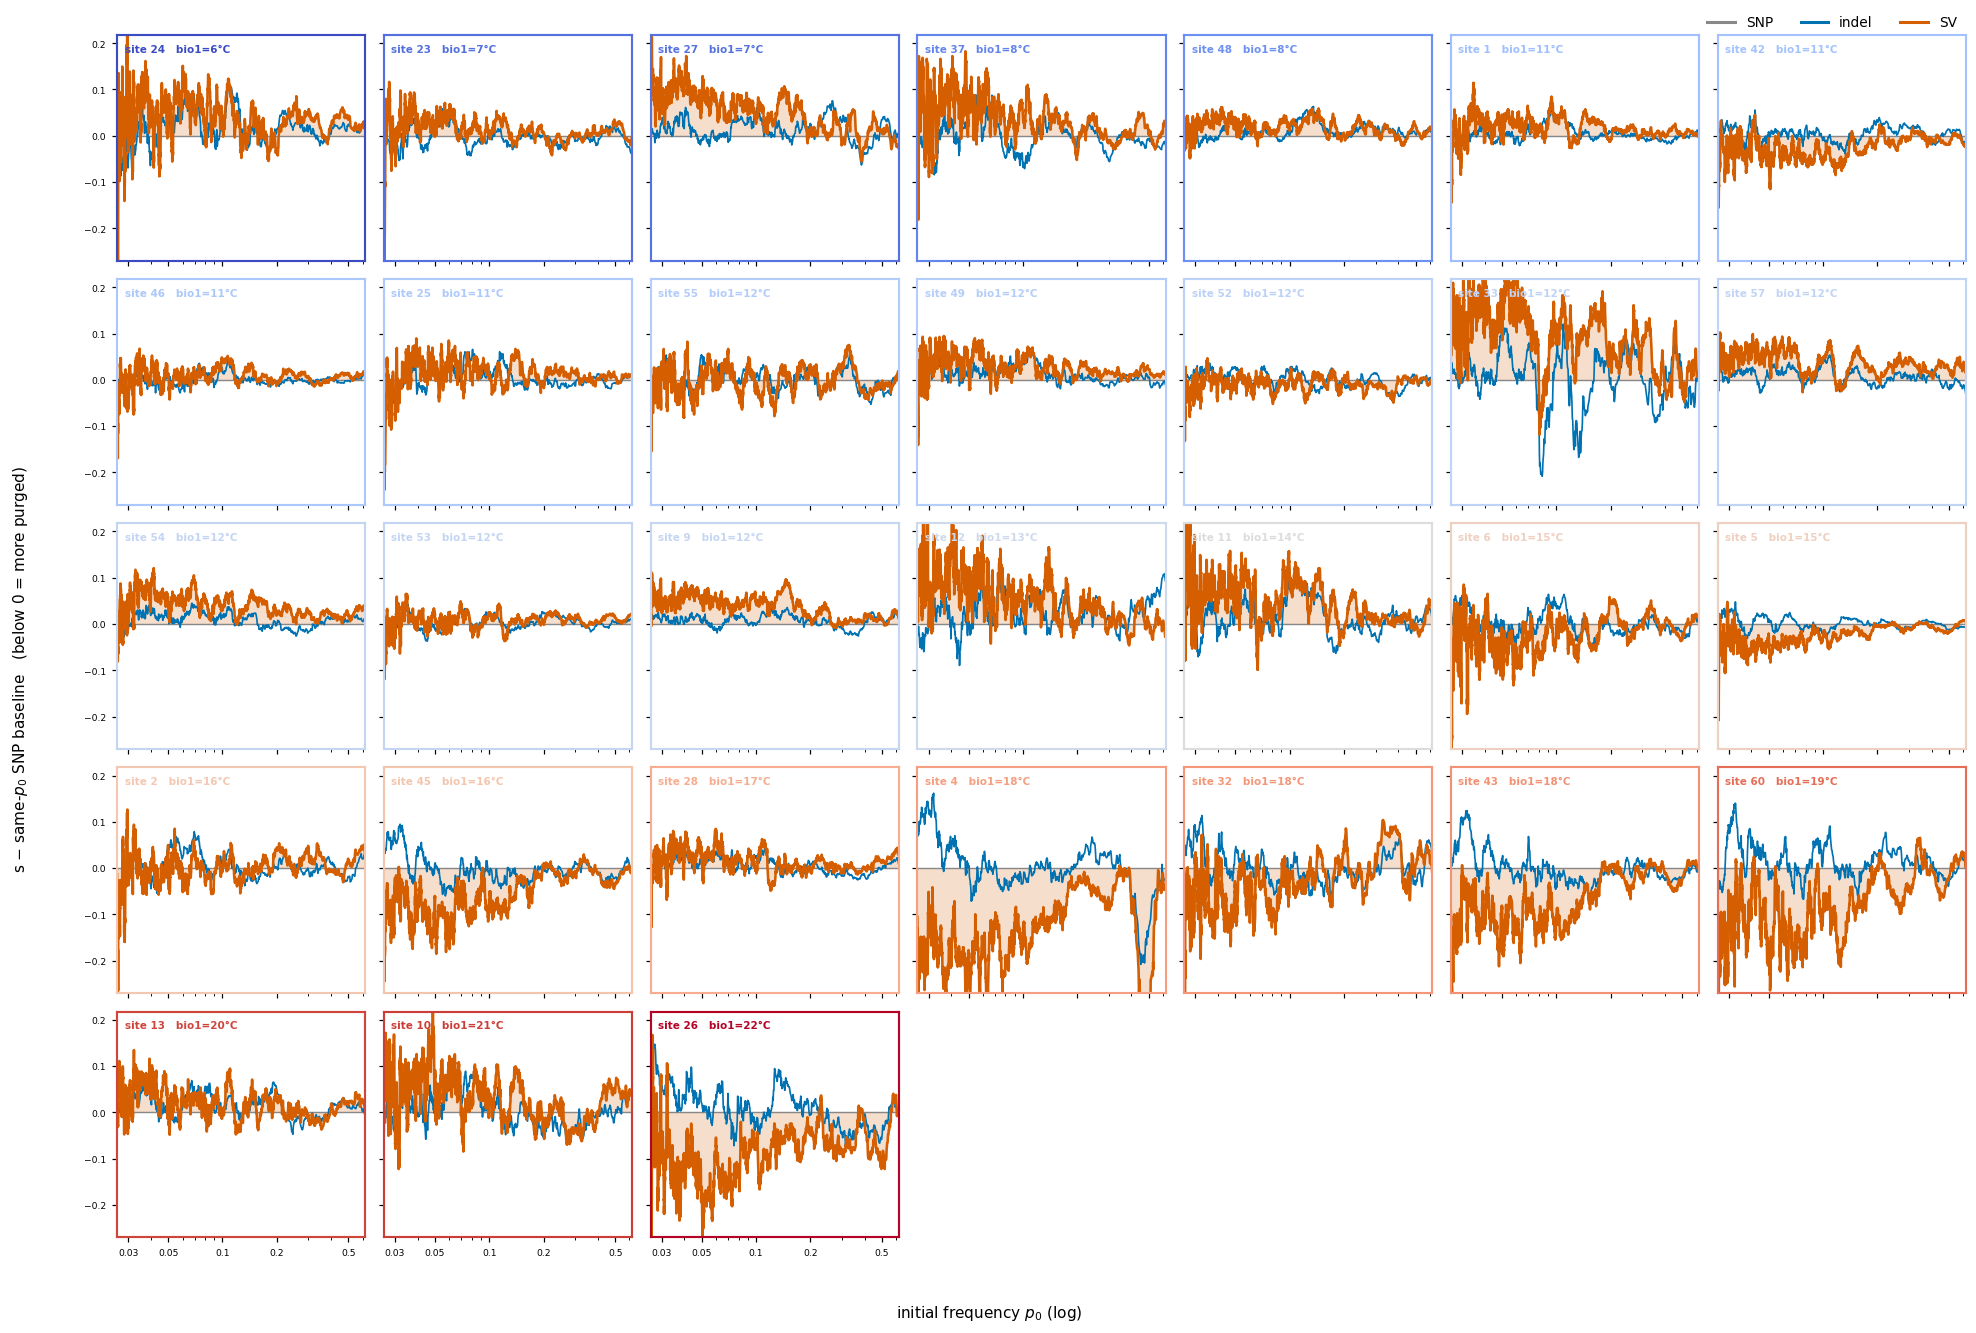

ylim=(-0.26974908835356504, 0.21778041574544996) (robust 0.5/99.5 pct — excursions beyond this run off-panel)


In [3]:

XTICKS = [0.03, 0.05, 0.1, 0.2, 0.5]; XLIM = (0.026, 0.62)

def panel_grid(cv_dict, xlim, xticks, mark_zones=False, ylim=None, logx=True):
    vis = []
    for s in sites:
        for cl in ["SV", "indel"]:
            p0c, rc = cv_dict[s][cl]
            m = (p0c >= xlim[0]) & (p0c <= xlim[1]) & np.isfinite(rc)
            vis.append(rc[m])
    vis = np.concatenate(vis)
    if ylim is None:
        lo, hi = np.nanpercentile(vis, [0.5, 99.5])       # robust: unfiltered tails are wild
        pad = 0.08 * (hi - lo); ylim = (lo - pad, hi + pad)
    ncol = 7; nrow = int(np.ceil(len(sites) / ncol))
    norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
    fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.4 * nrow), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax in axes[len(sites):]:
        ax.axis("off")
    for i, s in enumerate(sites):
        ax = axes[i]; cv = cv_dict[s]
        ax.axhline(0, color="k", lw=0.7, ls=":")
        if mark_zones:
            ax.axvspan(xlim[0], EPS, color="0.85", alpha=0.55, lw=0)      # EPS-clipped
            ax.axvline(P0_BOUND, color="0.45", lw=0.8, ls="--")           # production cutoff
        for cl, lw in [("SNP", 0.9), ("indel", 1.1), ("SV", 1.7)]:
            p0c, rc = cv[cl]
            m = (p0c >= xlim[0]) & (p0c <= xlim[1])
            if cl == "SV":
                ax.fill_between(p0c[m], 0, rc[m], color=COL["SV"], alpha=0.20, lw=0)
            ax.plot(p0c[m], rc[m], "-", color=COL[cl], lw=lw)
        c = cmap(norm(meta.bio1.iloc[i]))
        ax.annotate(f"site {int(s)}   bio1={meta.bio1.iloc[i]:.0f}°C", xy=(0.03, 0.96),
                    xycoords="axes fraction", va="top", ha="left", fontsize=6.8,
                    color=c, fontweight="bold")
        for sp in ax.spines.values():
            sp.set_color(c); sp.set_linewidth(1.4)
        if logx:
            ax.set_xscale("log")
        ax.set_xlim(*xlim)
        if xticks:
            ax.set_xticks(xticks); ax.set_xticklabels([str(t) for t in xticks], fontsize=6)
        ax.tick_params(labelsize=6)
    axes[0].set_ylim(*ylim)
    return fig, axes, ylim

fig, axes, yl = panel_grid(curves, XLIM, XTICKS)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_prodrange.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"ylim={yl} (robust 0.5/99.5 pct — excursions beyond this run off-panel)")


### 1b. Same twin, larger window — smoother

Identical to §1 (same unfiltered data, same production $p_0$ range, same matched-bandwidth rule)
with the window widened **619 → 2001**, which averages ~3× more variants per point. The
site-to-site *noise* drops sharply while the cold→hot ordering of the SV curve stays put — the
pattern is a property of the data, not of how hard the curve is smoothed (§4 quantifies this over
a 40× window range).

Note the y-scale is auto-set per figure, so it tightens here as the excursions shrink; compare
*shapes and signs*, not absolute amplitudes, against §1.

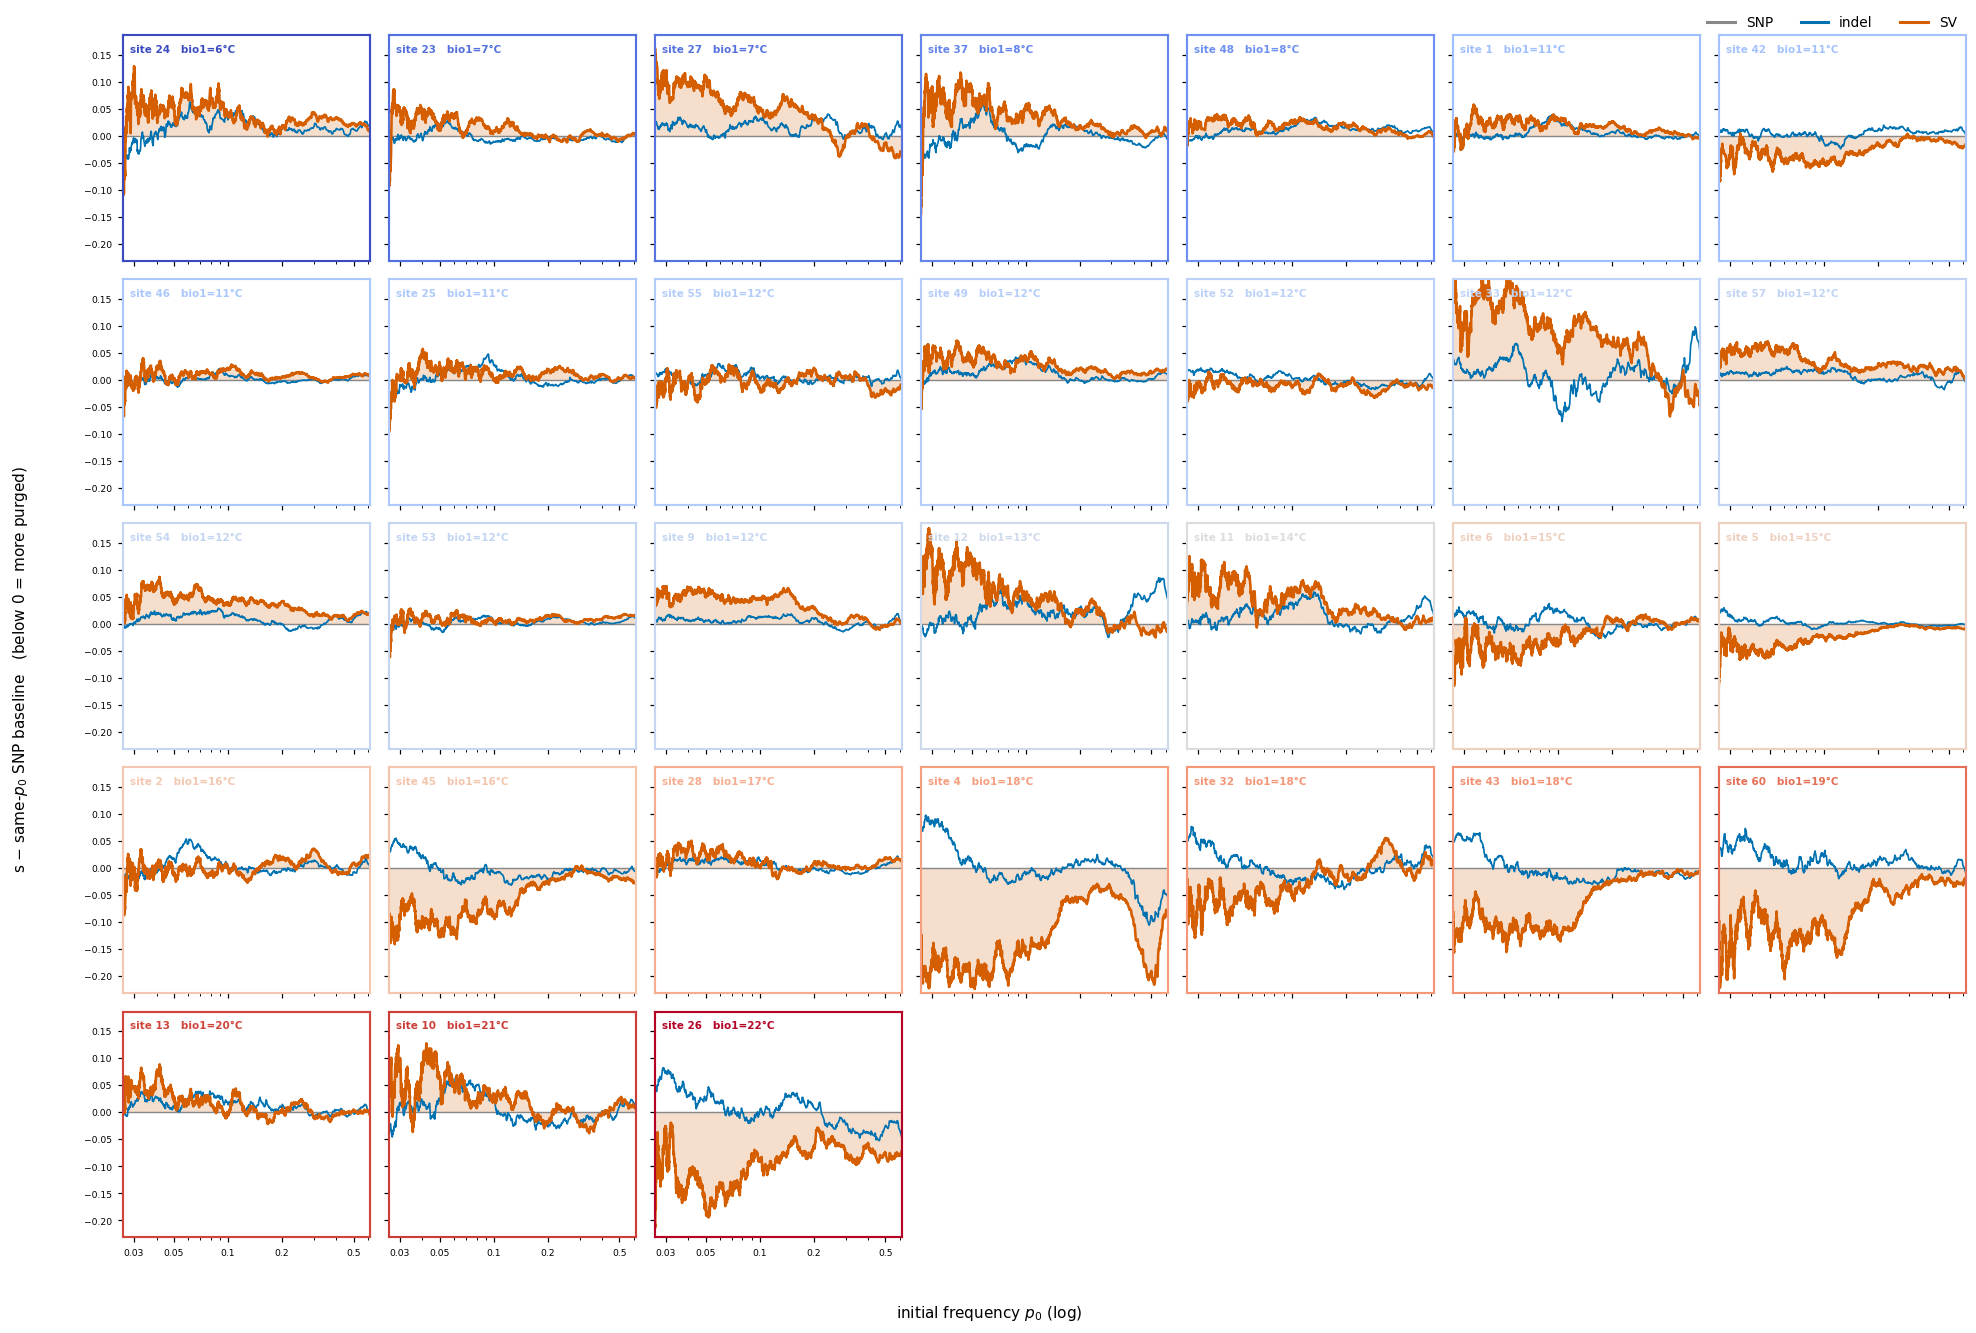

window=2001 (matched)  ylim=(-0.23125238341127313, 0.18634359282045873)
  SV median shift=+0.0164  below baseline at 12/31 sites
  rho bio1 =-0.451 (p=0.0108)
  rho bio18=+0.733 (p=0.0000)


In [4]:

WIN_SMOOTH = 2001
curves_smooth = {s: site_excess(s, WIN_SMOOTH) for s in sites}
fig, axes, yl = panel_grid(curves_smooth, XLIM, XTICKS)
fig.supxlabel("initial frequency $p_0$ (log)", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_prodrange_win{WIN_SMOOTH}.png",
            dpi=130, bbox_inches="tight")
plt.show()
sh_sm = np.array([mean_over(*curves_smooth[s]["SV"], *XLIM) for s in sites])
print(f"window={WIN_SMOOTH} (matched)  ylim={yl}")
print(f"  SV median shift={np.nanmedian(sh_sm):+.4f}  below baseline at {int((sh_sm<0).sum())}/{len(sh_sm)} sites")
print(f"  rho bio1 ={stats.spearmanr(bio1, sh_sm).statistic:+.3f} (p={stats.spearmanr(bio1, sh_sm).pvalue:.4f})")
print(f"  rho bio18={stats.spearmanr(bio18, sh_sm).statistic:+.3f} (p={stats.spearmanr(bio18, sh_sm).pvalue:.4f})")


### 1c. Same smoothed twin, x-axis extended down to the lowest $p_0$

Identical curves to §1b (same unfiltered data, same matched window 2001) — the **only** change is
the left x-limit, which now runs to the actual minimum $p_0$ in the data
($\approx5\times10^{-5}$) instead of stopping at the production 0.026. So this is §1b plus the
entire rare region the production panel never showed.

Zone markers are on here because they matter once $p_0<0.02$ is in view: the **dashed line** is the
production $p_0\ge0.02$ cutoff, and the **grey band** is the EPS-clipped zone ($p_0\le10^{-3}$,
1.25% of SVs) where every variant shares an identical *fabricated* starting logit — a smoother
curve there is still a smoothed artefact, not evidence.

The y-scale auto-expands to fit the rare region, so the 0.026–0.62 part of each panel looks
flatter here than in §1b; that is a scale change, not a change in the data.

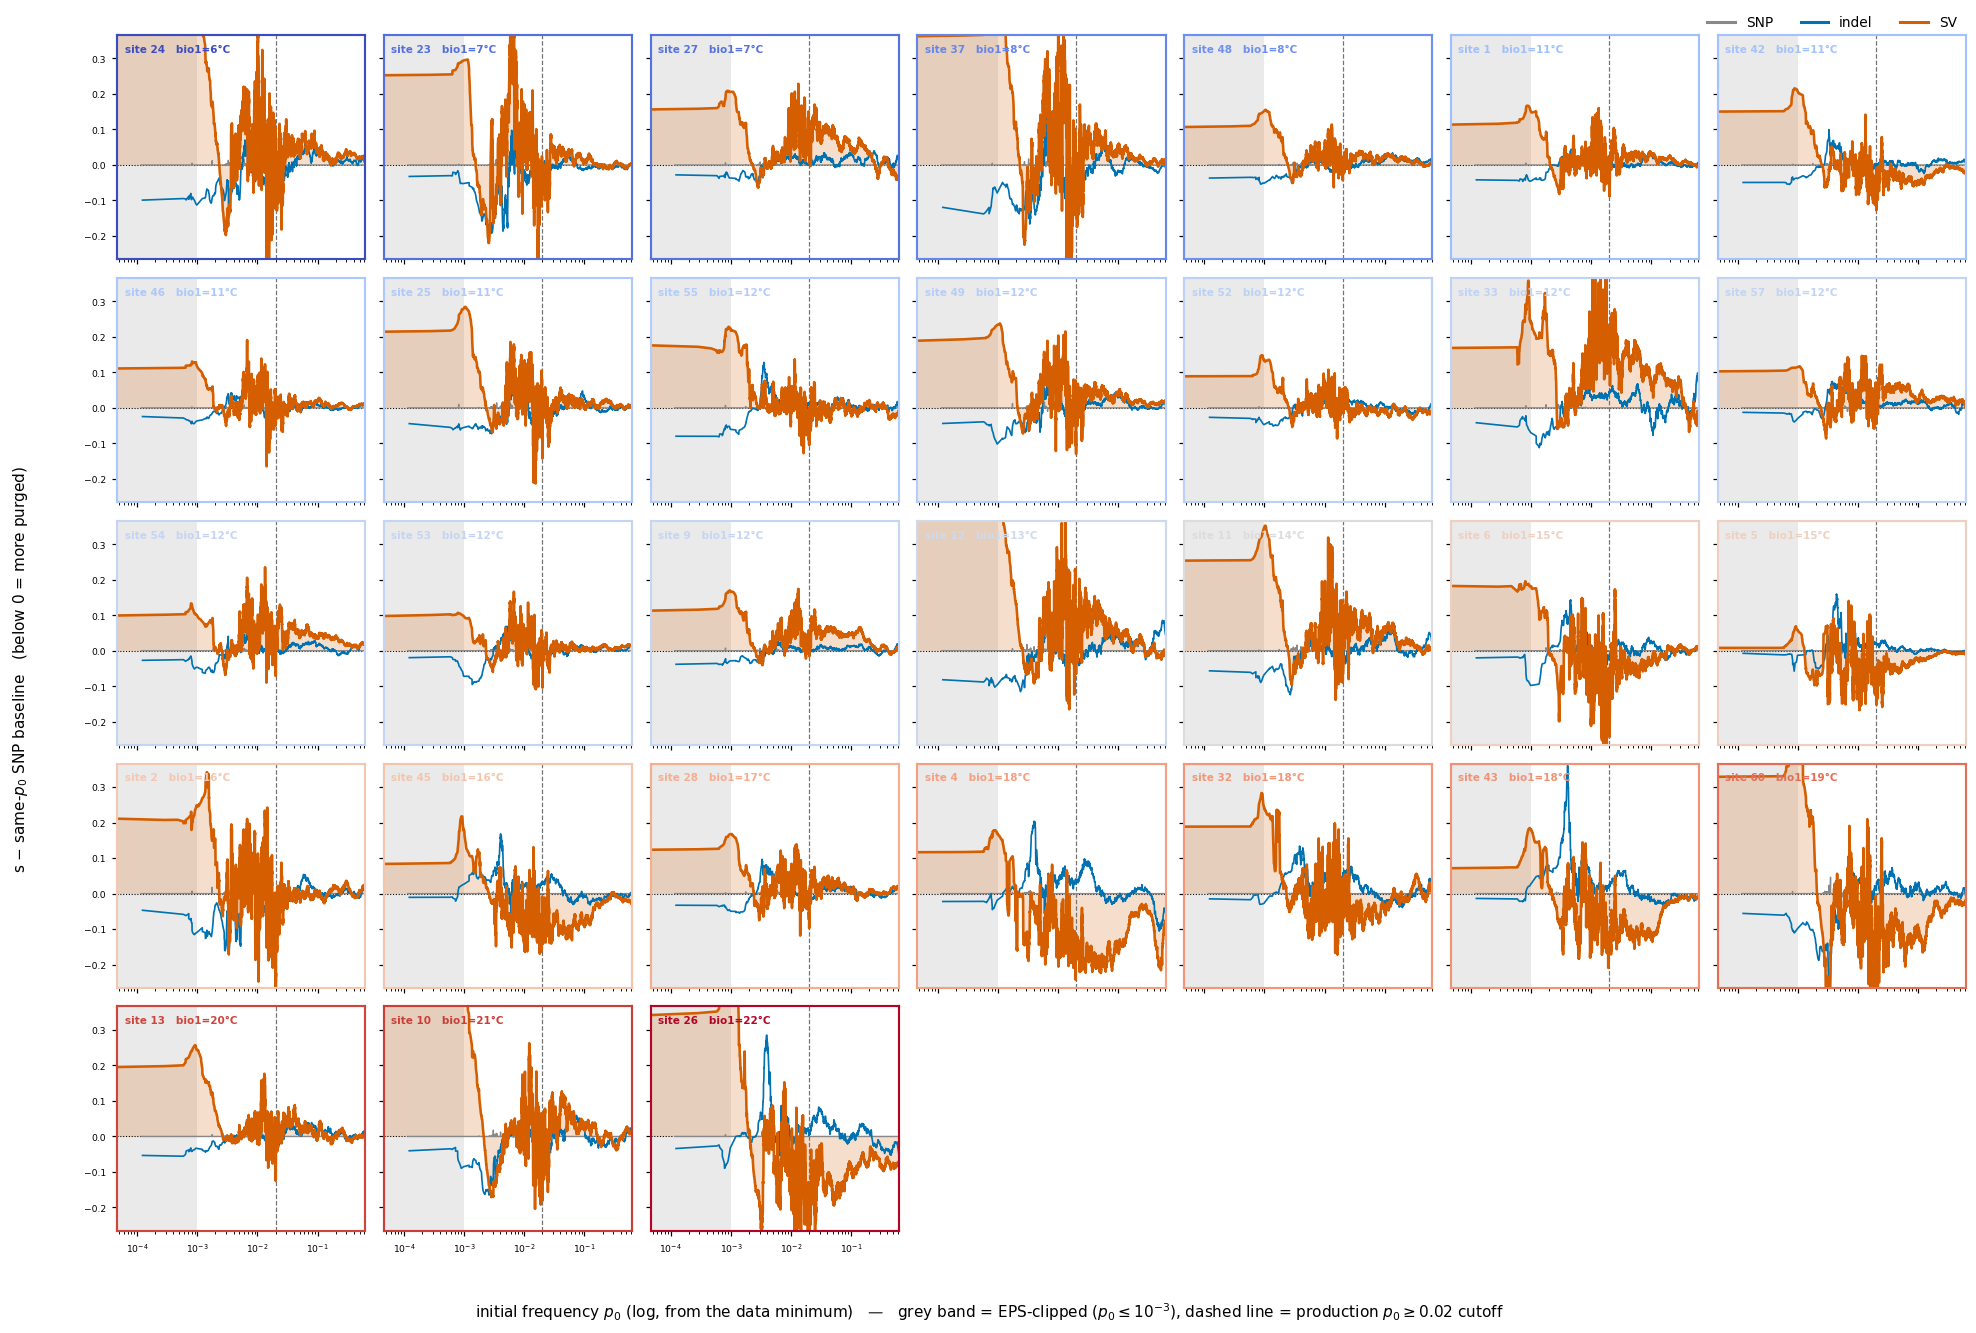

window=2001 (matched)  xlim=(0.00005, 0.62)  ylim=(-0.26572450241092366, 0.36615006449488624)
  below production cutoff  median=+0.0253 neg=9/31  rho bio1=-0.614  rho bio18=+0.788
  production range         median=+0.0056 neg=12/31  rho bio1=-0.458  rho bio18=+0.729


In [5]:

LOW = (p0_sv.min(), 0.62)          # same as §1b but left edge at the true data minimum
fig, axes, yl = panel_grid(curves_smooth, LOW, None, mark_zones=True)
fig.supxlabel("initial frequency $p_0$ (log, from the data minimum)   —   grey band = EPS-clipped "
              "($p_0\\leq10^{-3}$), dashed line = production $p_0\\geq0.02$ cutoff", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_lowp0_win{WIN_SMOOTH}.png",
            dpi=130, bbox_inches="tight")
plt.show()
print(f"window={WIN_SMOOTH} (matched)  xlim=({LOW[0]:.5f}, {LOW[1]})  ylim={yl}")
for lo, hi, lab in [(LOW[0], P0_BOUND, "below production cutoff"), (P0_BOUND, 0.62, "production range")]:
    sh = np.array([mean_over(*curves_smooth[s]["SV"], lo, hi) for s in sites])
    g = np.isfinite(sh)
    print(f"  {lab:<24} median={np.nanmedian(sh):+.4f} neg={int((sh[g]<0).sum())}/{int(g.sum())}  "
          f"rho bio1={stats.spearmanr(bio1[g], sh[g]).statistic:+.3f}  "
          f"rho bio18={stats.spearmanr(bio18[g], sh[g]).statistic:+.3f}")


### 1d. Same smoothed twin, **linear** (raw) $p_0$ axis

§1b again — identical curves, identical window 2001 — with the x-axis as **raw frequency** instead
of log. Worth seeing because log-x visually oversells the rare end: on a linear axis it is obvious
that essentially all the structure lives **below $p_0\approx0.1$** and that above ~0.2 both classes
are flat and near zero across most sites. The cold/hot split reads the same, so it is not an
artefact of log-scaling — but the honest description is a *low-frequency* effect, not a
whole-spectrum one.

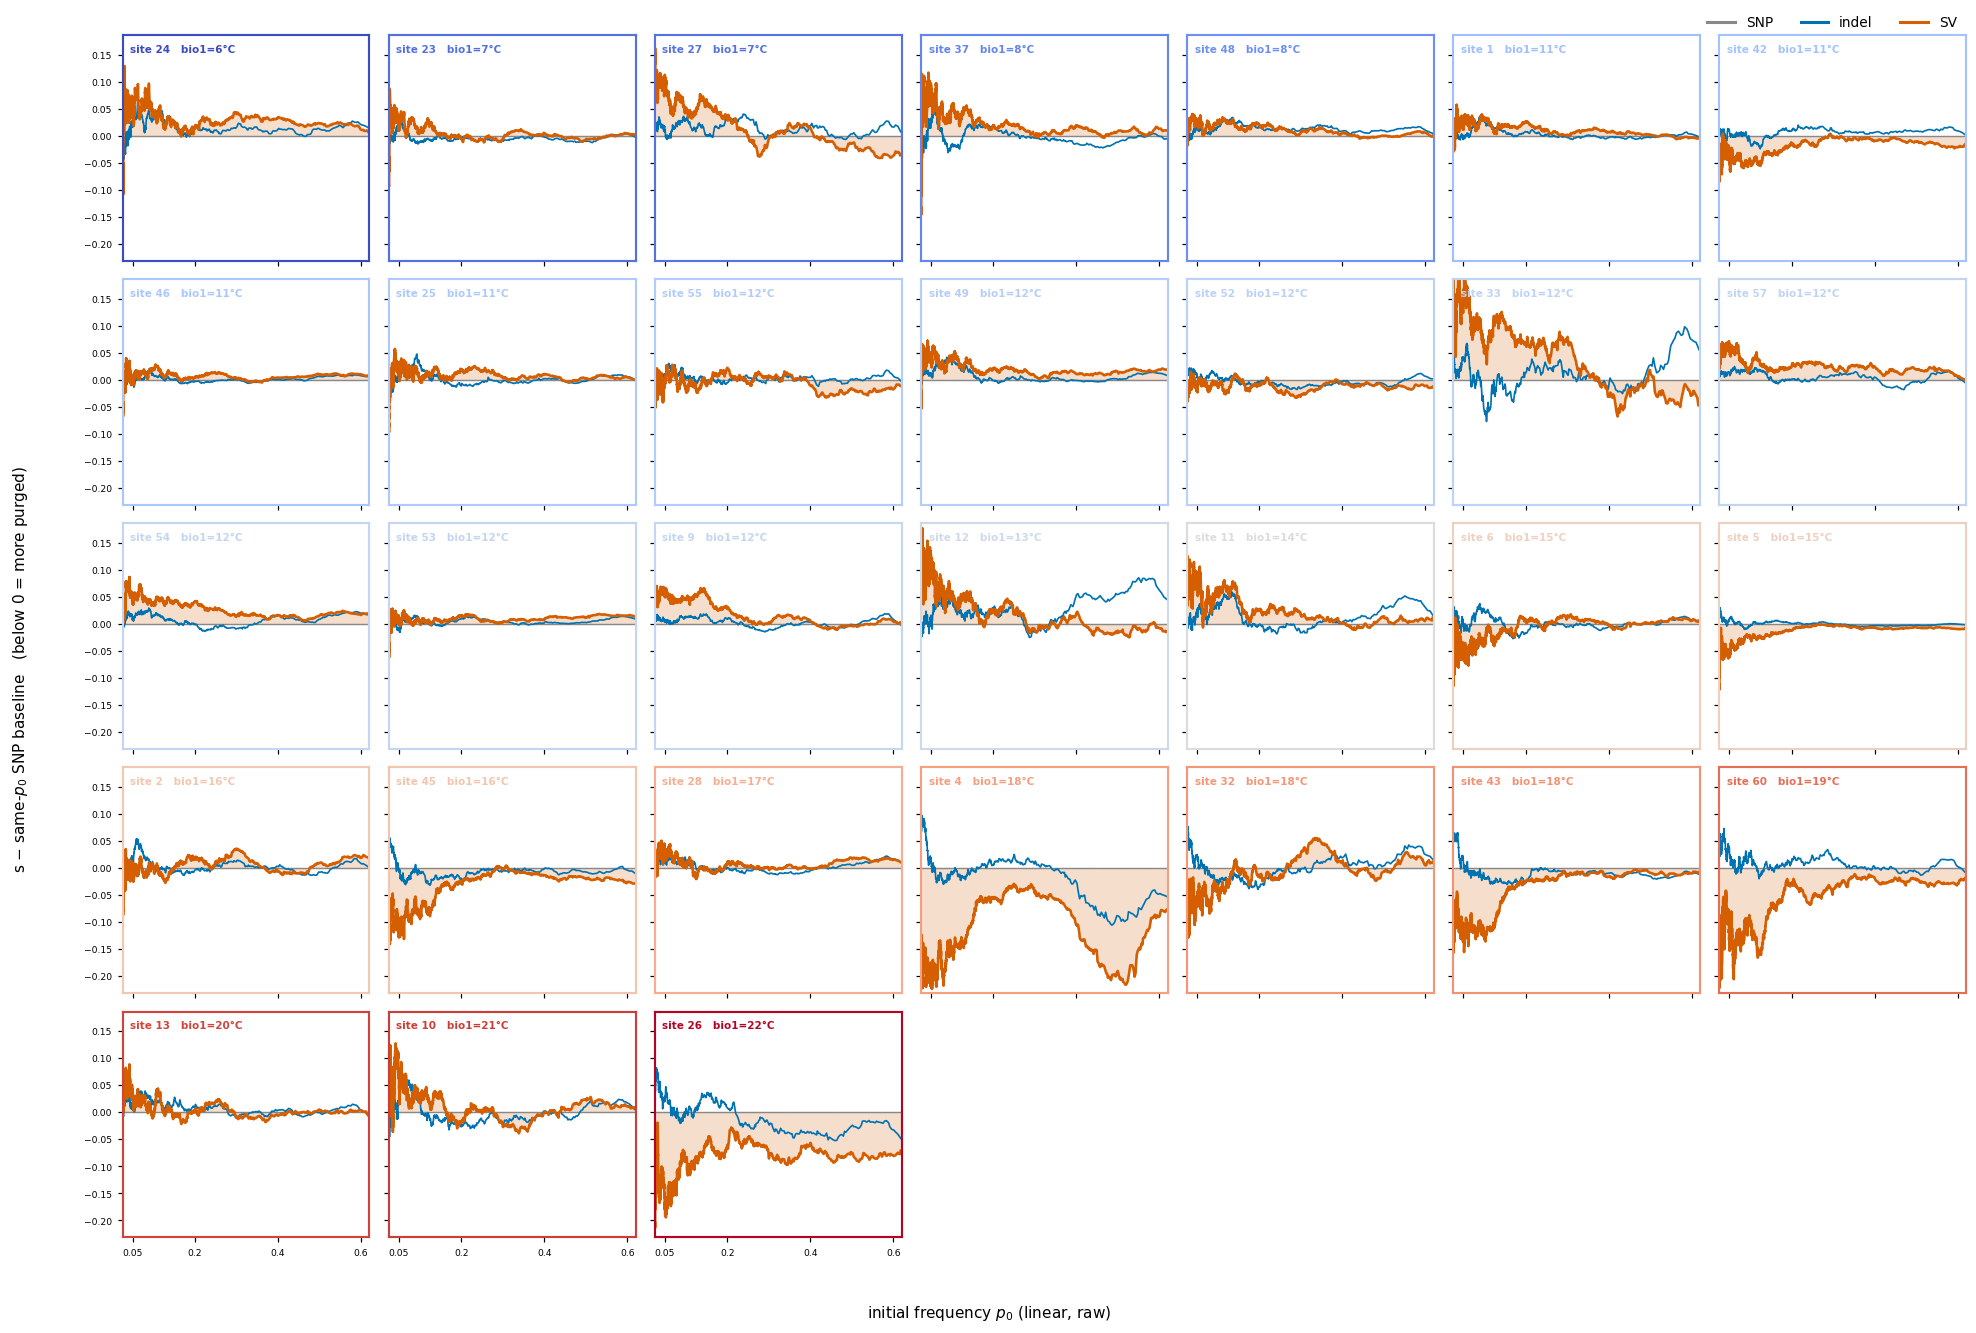

window=2001, LINEAR x  ylim=(-0.23125238341127313, 0.18634359282045873)


In [6]:

fig, axes, yl = panel_grid(curves_smooth, XLIM, [0.05, 0.2, 0.4, 0.6], logx=False)
fig.supxlabel("initial frequency $p_0$ (linear, raw)", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_prodrange_win{WIN_SMOOTH}_linearx.png",
            dpi=130, bbox_inches="tight")
plt.show()
print(f"window={WIN_SMOOTH}, LINEAR x  ylim={yl}")


## 2. Full $p_0$ range — what the boundary filter was hiding

Same curves extended over the entire frequency spectrum. The **dashed line** marks the production
$p_0 \ge 0.02$ cutoff (everything left of it is newly admitted — 71.6% of all SVs) and the **grey
band** marks the EPS-clipped zone ($p_0 \le 10^{-3}$), where starting logits are fabricated and
nothing should be read as biology.

This is the panel that shows why the filters exist: left of the dashed line the SV curve is a
local median over a handful of ultra-rare variants whose logit slopes are boundary-dominated, so
it thrashes across the full y-range and buries the indel line.

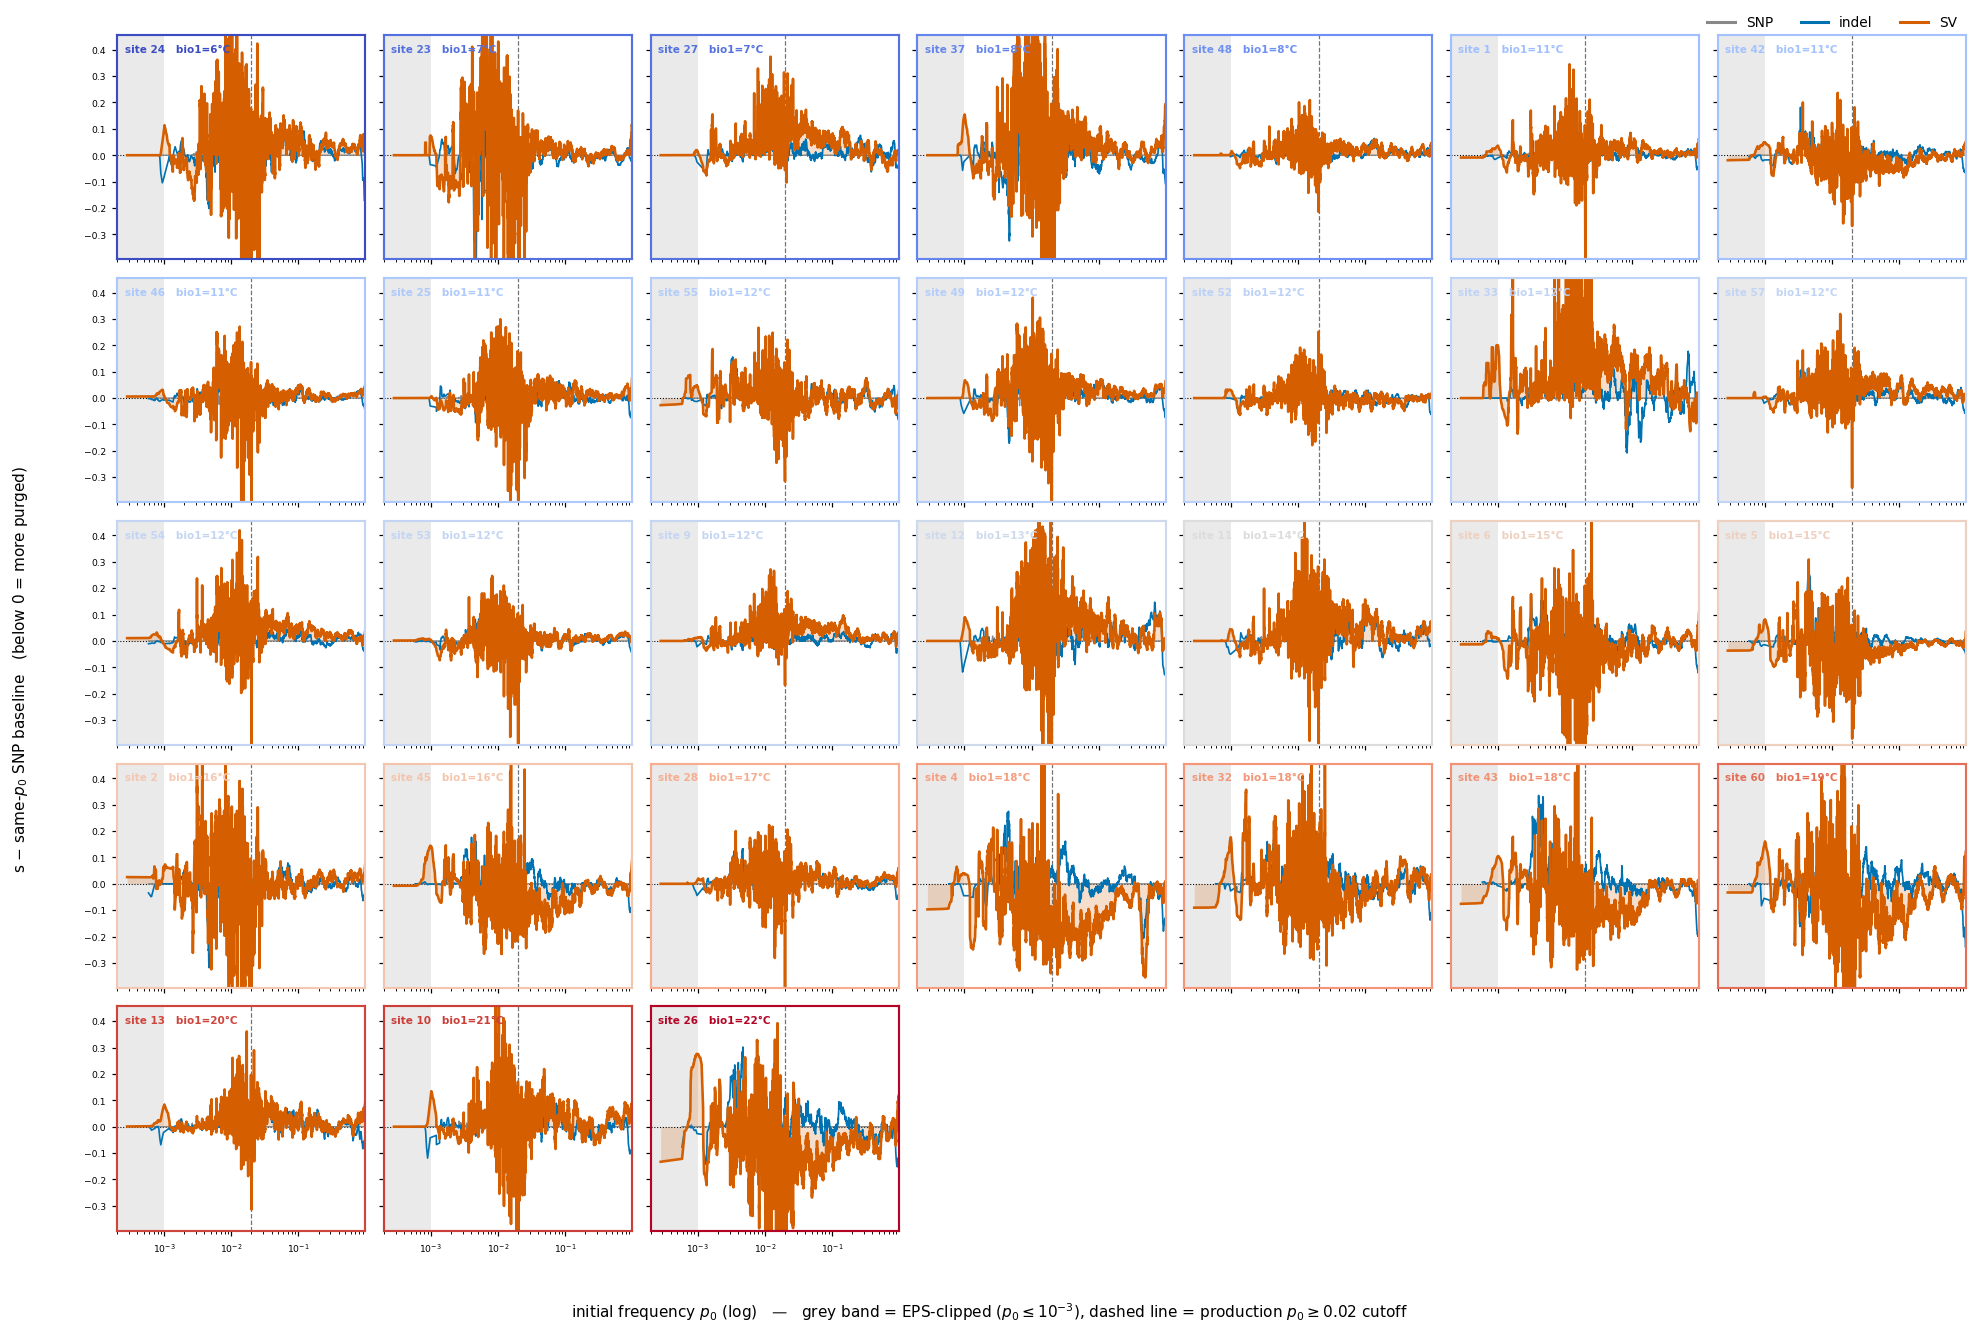

ylim=(-0.39485525175031144, 0.45578433628179216)


In [7]:

FULL = (max(p0_sv.min(), 2e-4), 0.99)
fig, axes, yl = panel_grid(curves, FULL, None, mark_zones=True)
fig.supxlabel("initial frequency $p_0$ (log)   —   grey band = EPS-clipped ($p_0\\leq10^{-3}$), "
              "dashed line = production $p_0\\geq0.02$ cutoff", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_fullrange.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"ylim={yl}")


### 2b. Full range, heavily smoothed — the readable version

The §2 full-range panel at a much wider window (**8001**), which is where smoothing helps most:
across the whole spectrum there are 226k SVs, so even this wide a window is only ~3.5% of them.
This turns the unreadable §2 thrash into something interpretable, and makes the shape of the
newly-admitted $p_0<0.02$ region (left of the dashed line) visible instead of noise-dominated.

Still do not read the grey EPS-clipped band as biology — those starting logits are fabricated by
the clip, and smoothing a fabricated quantity does not make it real.

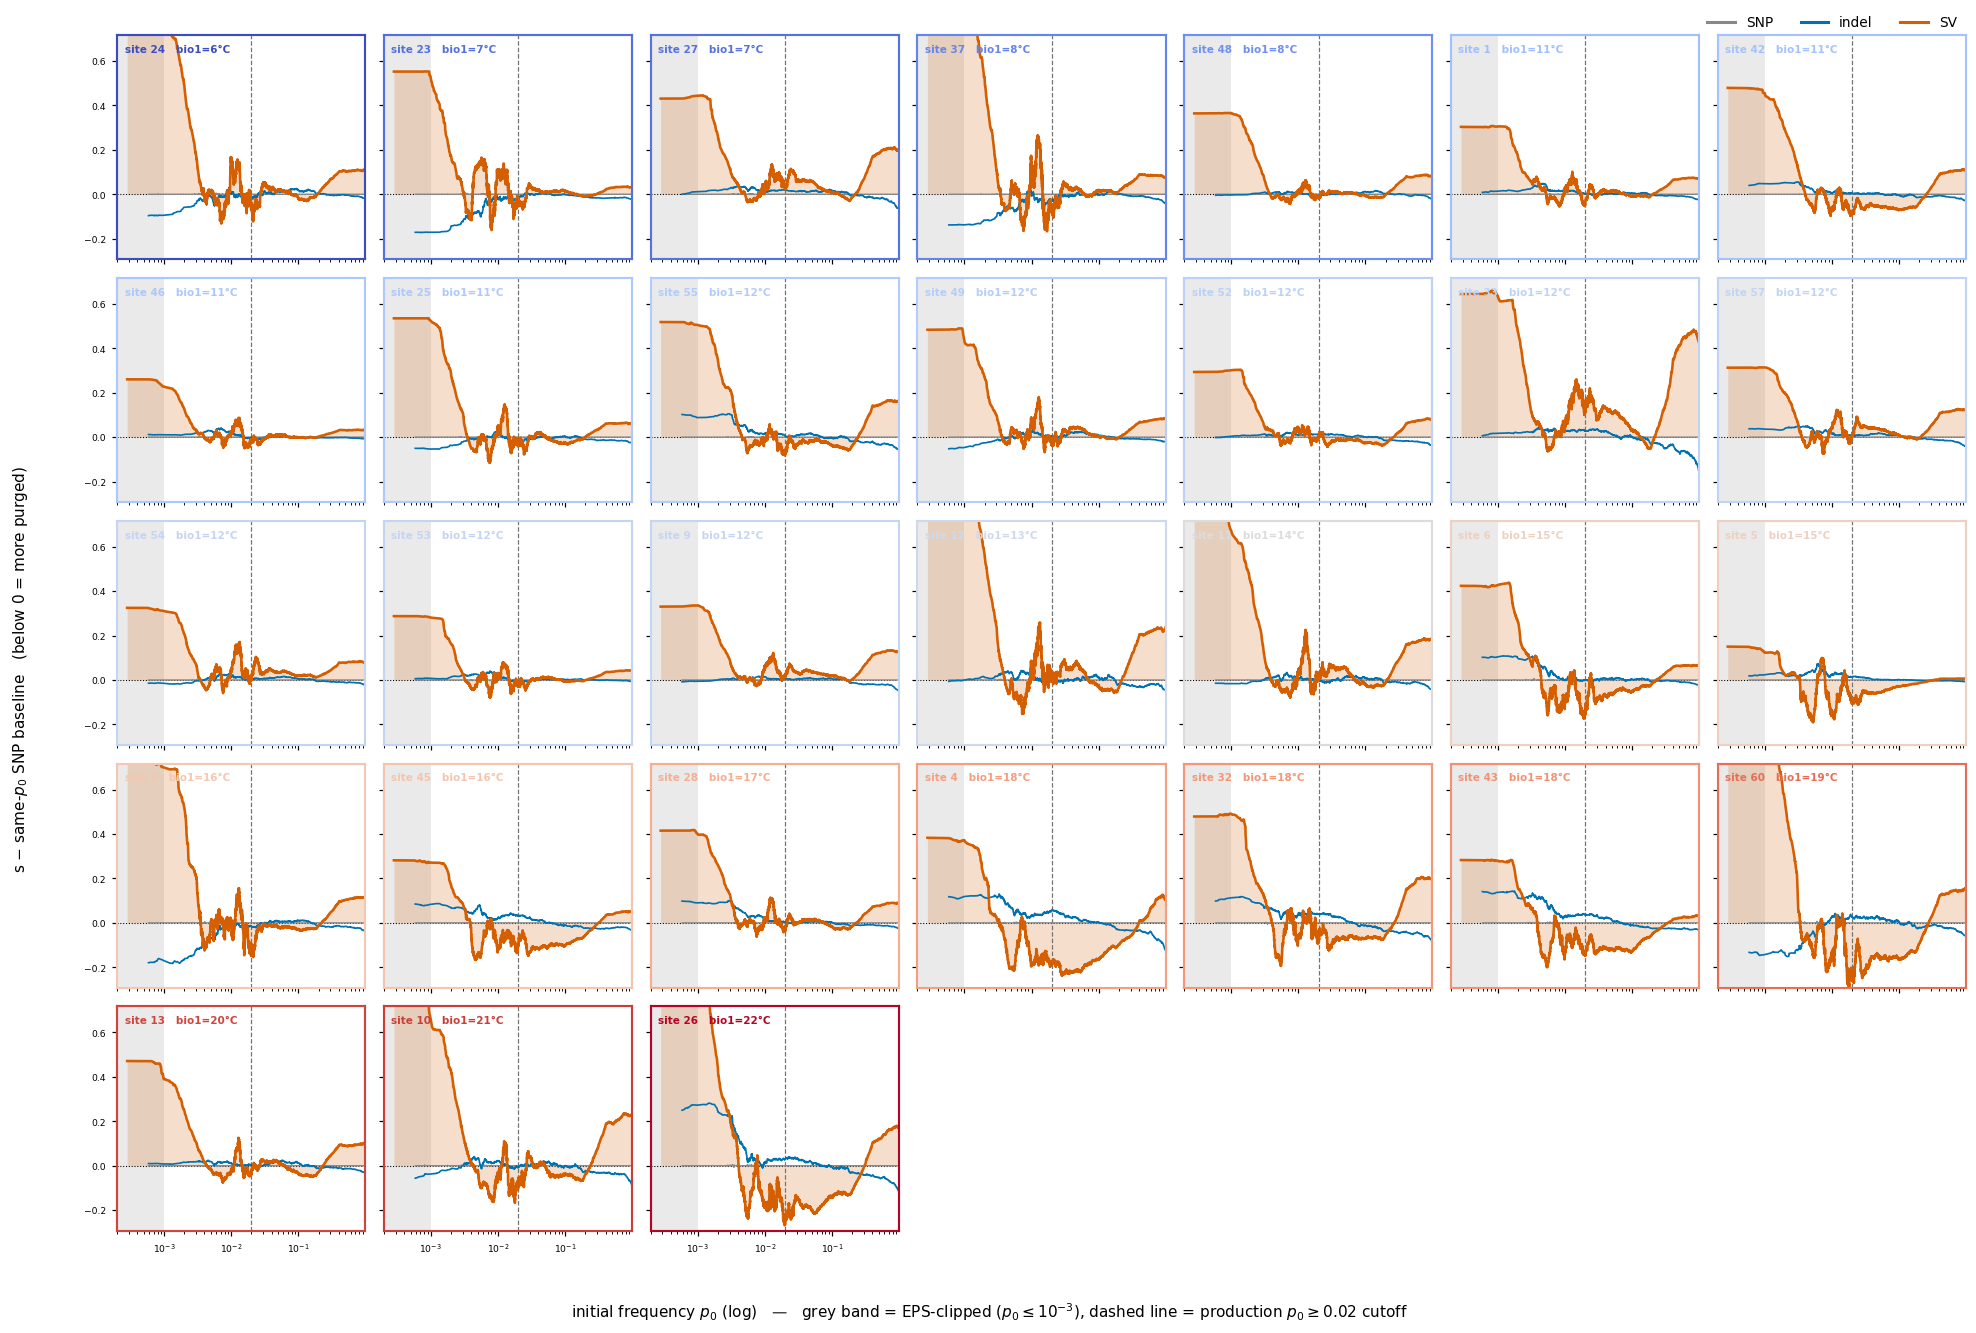

window=8001 (matched)  ylim=(-0.29284296599341736, 0.7165651328065147)
  (production-range shift at this window) rho bio1 =-0.501  rho bio18=+0.721


In [8]:

WIN_FULL_SMOOTH = 8001
curves_vsmooth = {s: site_excess(s, WIN_FULL_SMOOTH) for s in sites}
fig, axes, yl = panel_grid(curves_vsmooth, FULL, None, mark_zones=True)
fig.supxlabel("initial frequency $p_0$ (log)   —   grey band = EPS-clipped ($p_0\\leq10^{-3}$), "
              "dashed line = production $p_0\\geq0.02$ cutoff", y=0.005, fontsize=10)
fig.supylabel("s − same-$p_0$ SNP baseline   (below 0 = more purged)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["SNP", "indel", "SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
fig.savefig(f"{PLOTS}/s_distribution_by_site_nofilter_fullrange_win{WIN_FULL_SMOOTH}.png",
            dpi=130, bbox_inches="tight")
plt.show()
sh_v = np.array([mean_over(*curves_vsmooth[s]["SV"], *XLIM) for s in sites])
print(f"window={WIN_FULL_SMOOTH} (matched)  ylim={yl}")
print(f"  (production-range shift at this window) rho bio1 ={stats.spearmanr(bio1, sh_v).statistic:+.3f}  "
      f"rho bio18={stats.spearmanr(bio18, sh_v).statistic:+.3f}")


## 3. Climate gradient — the quantitative claim

The per-site mean de-trended SV shift vs bio1 (temperature) and bio18 (dry-summer precipitation).
This is where the pattern lives as a single number per axis, and it is what should be read from
this notebook rather than the noisy panels above. Production (filtered) reference values:
**ρ(bio1) ≈ −0.44…−0.58, ρ(bio18) ≈ +0.62…+0.69**.

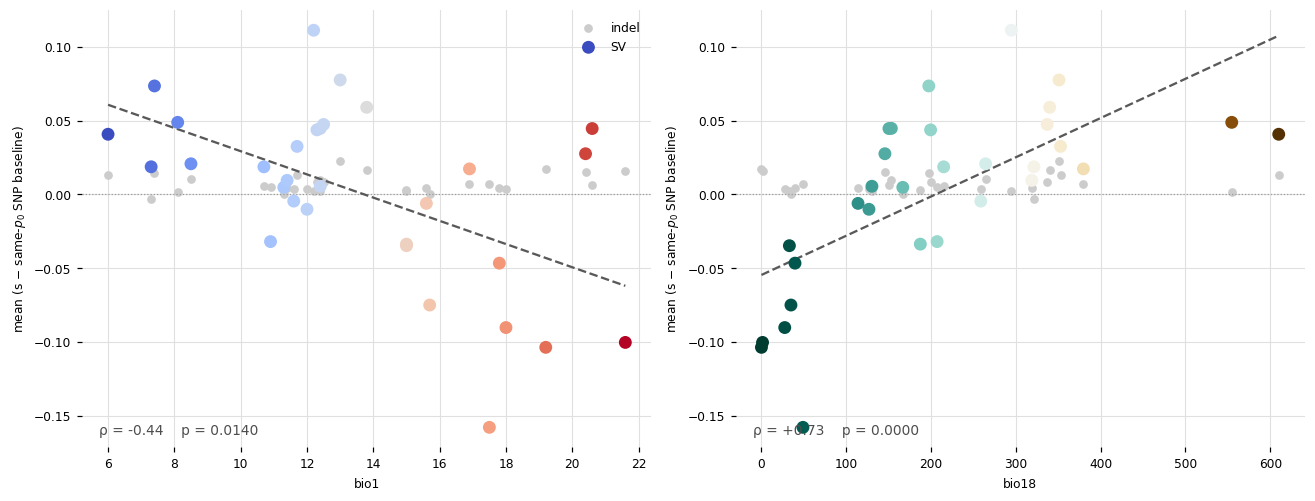

SV median shift=+0.0173  below baseline at 12/31 sites


In [9]:

shift = np.array([mean_over(*curves[s]["SV"], *XLIM) for s in sites])
shift_ind = np.array([mean_over(*curves[s]["indel"], *XLIM) for s in sites])

fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, (cvar, cvals, cmap_name) in zip(axs, [("bio1", bio1, "coolwarm"), ("bio18", bio18, "BrBG_r")]):
    ax.set_axisbelow(True); ax.grid(color="0.88", lw=0.7)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.axhline(0, color="0.6", lw=0.8, ls=":")
    ax.scatter(cvals, shift_ind, c="0.8", s=22, label="indel")
    ax.scatter(cvals, shift, c=cvals, cmap=cmap_name, s=55, label="SV", zorder=3)
    r = stats.spearmanr(cvals, shift)
    b, a0 = np.polyfit(cvals, shift, 1); xs = np.array([cvals.min(), cvals.max()])
    ax.plot(xs, a0 + b * xs, color="0.35", lw=1.5, ls="--")
    ax.annotate(f"ρ = {r.statistic:+.2f}    p = {r.pvalue:.4f}", xy=(0.03, 0.03),
                xycoords="axes fraction", fontsize=9, color="0.3")
    ax.set_xlabel(cvar); ax.set_ylabel("mean (s − same-$p_0$ SNP baseline)")
axs[0].legend(frameon=False, loc="upper right")
fig.tight_layout(); fig.savefig(f"{PLOTS}/s_nofilter_climate_scatter.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"SV median shift={np.nanmedian(shift):+.4f}  below baseline at {int((shift<0).sum())}/{len(shift)} sites")


## 4. Window sweep — is any of this a bandwidth choice?

The shift and its climate correlations recomputed over a 40× range of (matched) window sizes, and
over four $p_0$ regions — including the **newly-included** $p_0<0.02$ band on its own, to see
whether the previously-excluded variants behave differently from the retained ones.

In [10]:

RANGES = {"prod (0.026-0.62)": (0.026, 0.62), "tail (0.026-0.10)": (0.026, 0.10),
          "newly-included (<0.02)": (0.0, 0.02), "full (all p0)": (0.0, 1.0)}
rows = []
for win in [51, 155, 619, 2001]:
    cw = {s: site_excess(s, win) for s in sites}
    for rname, (lo, hi) in RANGES.items():
        sh = np.array([mean_over(*cw[s]["SV"], lo, hi) for s in sites])
        g = np.isfinite(sh)
        if g.sum() < 10:
            continue
        r1 = stats.spearmanr(bio1[g], sh[g]); r18 = stats.spearmanr(bio18[g], sh[g])
        rows.append(dict(win=win, p0_region=rname, n_sites=int(g.sum()),
                         median=round(float(np.nanmedian(sh)), 4), n_neg=int((sh[g] < 0).sum()),
                         rho_bio1=round(r1.statistic, 3), p_bio1=round(r1.pvalue, 4),
                         rho_bio18=round(r18.statistic, 3), p_bio18=round(r18.pvalue, 4)))
sweep = pd.DataFrame(rows)
sweep.to_csv(f"{G}/nofilter_window_sweep.csv", index=False)
display(sweep)


,win,p0_region,n_sites,median,n_neg,rho_bio1,p_bio1,rho_bio18,p_bio18
0,51,prod (0.026-0.62),31,0.0156,12,-0.441,0.0131,0.725,0.0
1,51,tail (0.026-0.10),31,0.0166,12,-0.420,0.0186,0.729,0.0
2,51,newly-included (<0.02),31,0.0273,8,-0.518,0.0029,0.778,0.0
3,51,full (all p0),31,0.0242,8,-0.495,0.0046,0.772,0.0
4,155,prod (0.026-0.62),31,0.0138,12,-0.422,0.0180,0.728,0.0
5,155,tail (0.026-0.10),31,0.0168,12,-0.414,0.0205,0.729,0.0
6,155,newly-included (<0.02),31,0.0292,8,-0.537,0.0018,0.795,0.0
7,155,full (all p0),31,0.0229,8,-0.486,0.0055,0.775,0.0
8,619,prod (0.026-0.62),31,0.0173,12,-0.437,0.0140,0.727,0.0
9,619,tail (0.026-0.10),31,0.0201,12,-0.424,0.0175,0.723,0.0


## 5. ⚠️ CORRECTION to §1–§2 — no clipping, and a baseline matched by $p_0$ *width*

Sections 1–2 have **two defects**, both fixed here. Read this section in preference to them.

**(a) The window was matched by COUNT, not by $p_0$ WIDTH.** SV n=226,468 vs SNP n=25,000, so a
fixed 2001-point rank window spans a **~9× narrower $p_0$ range for SVs than for SNPs** — matching
the count does *not* match the bandwidth. It is worst in the rare tail: below $p_0=10^{-3}$ there
are 2,816 SVs but only **252** SNPs, so the SNP baseline cannot fill a 2001-point window locally and
reaches far right into much-higher-$p_0$ SNPs. The SV curve stays local, the baseline does not, and
the subtraction manufactures an offset — **this is what produced the apparent positive "plateau"** in
§1c. Direct proof it is not biology: in that zone both classes have the same clipped $p_0$
($\approx10^{-3}$) *and* the same median evolved AF (0.00145), so a genuinely local difference
would be ≈0.

> **FIX:** smooth both classes with a fixed **half-width in $\log_{10}p_0$** (0.15 dex, i.e.
> $\times1.41$) on a common grid, and return **NaN** wherever either class has fewer than 40 points
> in the window instead of silently borrowing distant data.

**(b) The logit clip fabricates the rare tail.** `s` is the slope of $\mathrm{logit}(p)$ and
$\mathrm{logit}(0)=-\infty$, so an EPS clip is *unavoidable* for the logit statistic — every variant
below EPS shares an identical fake starting logit (hence a perfectly flat shelf). Exact zeros are
only 0.021% of SV pool entries, but **10.78% sit below $10^{-3}$** and get clipped upward.

> **FIX:** compare three estimators on identical data — logit EPS=$10^{-3}$ (production), logit
> EPS=$10^{-6}$, and **linear** = OLS slope of *raw* frequency on generation (no log, no clip, no
> EPS anywhere). If the signal were a clipping artefact it would die on the linear estimator.

Precompute: `sv_adaptive/s_noclip_variants.npz` (all filters still off).

In [11]:

HALF_DEX, MIN_N = 0.15, 40          # smoothing half-width in log10(p0); per-class minimum
nz = np.load(f"{G}/s_noclip_variants.npz")
nmeta = pd.read_csv(f"{G}/s_noclip_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
nsites = nmeta.site.tolist()
nbio1 = nmeta.bio1.to_numpy()
nbio18 = _clim.reindex(nsites)["bio18"].to_numpy()
NP0 = {c: nz[f"p0_{c}"].astype(np.float64) for c in ["SNP", "indel", "SV"]}
NLP0 = {c: np.log10(NP0[c]) for c in NP0}
_lo = max(min(NLP0[c].min() for c in NLP0), np.log10(2e-5))
_hi = min(NLP0[c].max() for c in NLP0)
GRID = np.logspace(_lo, _hi, 160); LGRID = np.log10(GRID)

def matched_curve(site, tag, cls):
    """Median s for `cls` minus median s for SNP inside the SAME fixed log10(p0) window."""
    s_c = nz[f"{site}_{tag}_{cls}"].astype(np.float64)
    s_b = nz[f"{site}_{tag}_SNP"].astype(np.float64)
    lc, lb = NLP0[cls], NLP0["SNP"]
    exc = np.full(GRID.size, np.nan)
    for i, lg in enumerate(LGRID):
        mc = np.abs(lc - lg) <= HALF_DEX; mb = np.abs(lb - lg) <= HALF_DEX
        if int(mc.sum()) < MIN_N or int(mb.sum()) < MIN_N:
            continue
        exc[i] = np.nanmedian(s_c[mc]) - np.nanmedian(s_b[mb])
    return exc

def region_mean(exc, lo_p, hi_p):
    m = (GRID >= lo_p) & (GRID <= hi_p) & np.isfinite(exc)
    return np.nanmean(exc[m]) if m.any() else np.nan

_cov = pd.DataFrame({"p0": GRID,
                     "n_SNP": [int((np.abs(NLP0["SNP"] - lg) <= HALF_DEX).sum()) for lg in LGRID],
                     "n_SV": [int((np.abs(NLP0["SV"] - lg) <= HALF_DEX).sum()) for lg in LGRID]})
_use = (_cov.n_SNP >= MIN_N) & (_cov.n_SV >= MIN_N)
print(f"half-width={HALF_DEX} dex (x{10**HALF_DEX:.2f}), min n={MIN_N}/class")
print(f"  usable grid points (both classes): {int(_use.sum())}/{len(_cov)}")
print(f"  lowest usable p0 = {_cov.p0[_use].min():.5f}  <- below this the SNP class is too sparse for a")
print(f"     LOCAL baseline; now honest NaN instead of the distant-borrowing that made the §1c plateau.")
print(f"  (this floor is set by the 25k SNP SUBSAMPLE, not by the data: all 6.2M SNPs would push it ~250x lower)")

TAGS = {"e3": "logit EPS=1e-3 (production)", "e6": "logit EPS=1e-6",
        "lin": "LINEAR raw-freq slope (NO clip at all)"}
ncurves = {t: {s: matched_curve(s, t, "SV") for s in nsites} for t in TAGS}


half-width=0.15 dex (x1.41), min n=40/class
  usable grid points (both classes): 123/160
  lowest usable p0 = 0.00047  <- below this the SNP class is too sparse for a
     LOCAL baseline; now honest NaN instead of the distant-borrowing that made the §1c plateau.
  (this floor is set by the 25k SNP SUBSAMPLE, not by the data: all 6.2M SNPs would push it ~250x lower)


### 5a. Does the plateau survive? And does the gradient?

The plateau test is the direct answer to "are rare SVs really under positive selection?" — the mean
SV excess in the formerly-flat zone, per estimator.

In [12]:

print("PLATEAU CHECK -- mean SV excess at p0 <= 2e-3")
for t, lab in TAGS.items():
    vals = [np.nanmean(ncurves[t][s][(GRID <= 2e-3) & np.isfinite(ncurves[t][s])])
            for s in nsites if ((GRID <= 2e-3) & np.isfinite(ncurves[t][s])).any()]
    print(f"  {lab:<42} {np.mean(vals):+.5f}  (sd {np.std(vals):.5f}, n={len(vals)})" if vals
          else f"  {lab:<42} no usable grid points")

REGIONS = {"production (0.02-0.62)": (0.02, 0.62), "rare (usable low p0 -> 0.02)": (0.0, 0.02),
           "all usable p0": (0.0, 1.0)}
rows = []
print("\nCLIMATE GRADIENT per estimator (all filters off; matched log-p0 width)")
for t, lab in TAGS.items():
    print(f"  {lab}")
    for rname, (a, b) in REGIONS.items():
        sh = np.array([region_mean(ncurves[t][s], a, b) for s in nsites]); g = np.isfinite(sh)
        if g.sum() < 10:
            continue
        r1 = stats.spearmanr(nbio1[g], sh[g]); r18 = stats.spearmanr(nbio18[g], sh[g])
        rows.append(dict(estimator=t, region=rname, n_sites=int(g.sum()),
                         median=round(float(np.nanmedian(sh)), 6), n_neg=int((sh[g] < 0).sum()),
                         rho_bio1=round(r1.statistic, 3), p_bio1=round(r1.pvalue, 4),
                         rho_bio18=round(r18.statistic, 3), p_bio18=round(r18.pvalue, 4)))
        print(f"    {rname:<30} median={np.nanmedian(sh):+.5f} neg={int((sh[g]<0).sum())}/{int(g.sum())} "
              f"bio1 rho={r1.statistic:+.3f}(p={r1.pvalue:.4f}) bio18 rho={r18.statistic:+.3f}(p={r18.pvalue:.4f})")
noclip_summary = pd.DataFrame(rows)
noclip_summary.to_csv(f"{G}/noclip_matched_width_summary.csv", index=False)
display(noclip_summary)


PLATEAU CHECK -- mean SV excess at p0 <= 2e-3
  logit EPS=1e-3 (production)                +0.01003  (sd 0.00888, n=31)
  logit EPS=1e-6                             -0.00470  (sd 0.05804, n=31)
  LINEAR raw-freq slope (NO clip at all)     +0.00002  (sd 0.00003, n=31)

CLIMATE GRADIENT per estimator (all filters off; matched log-p0 width)
  logit EPS=1e-3 (production)
    production (0.02-0.62)         median=+0.00649 neg=12/31 bio1 rho=-0.467(p=0.0080) bio18 rho=+0.731(p=0.0000)
    rare (usable low p0 -> 0.02)   median=+0.01386 neg=7/31 bio1 rho=-0.551(p=0.0013) bio18 rho=+0.734(p=0.0000)
    all usable p0                  median=+0.01271 neg=9/31 bio1 rho=-0.520(p=0.0027) bio18 rho=+0.767(p=0.0000)
  logit EPS=1e-6
    production (0.02-0.62)         median=+0.00553 neg=12/31 bio1 rho=-0.488(p=0.0054) bio18 rho=+0.715(p=0.0000)
    rare (usable low p0 -> 0.02)   median=+0.01868 neg=10/31 bio1 rho=-0.415(p=0.0202) bio18 rho=+0.506(p=0.0037)
    all usable p0                  median=+0.

,estimator,region,n_sites,median,n_neg,rho_bio1,p_bio1,rho_bio18,p_bio18
0,e3,production (0.02-0.62),31,0.006489,12,-0.467,0.0080,0.731,0.0000
1,e3,rare (usable low p0 -> 0.02),31,0.013857,7,-0.551,0.0013,0.734,0.0000
2,e3,all usable p0,31,0.012710,9,-0.520,0.0027,0.767,0.0000
3,e6,production (0.02-0.62),31,0.005525,12,-0.488,0.0054,0.715,0.0000
4,e6,rare (usable low p0 -> 0.02),31,0.018677,10,-0.415,0.0202,0.506,0.0037
5,e6,all usable p0,31,0.012481,12,-0.478,0.0065,0.653,0.0001
6,lin,production (0.02-0.62),31,0.001177,10,-0.455,0.0101,0.748,0.0000
7,lin,rare (usable low p0 -> 0.02),31,0.000064,9,-0.589,0.0005,0.765,0.0000
8,lin,all usable p0,31,0.000719,11,-0.431,0.0155,0.748,0.0000


### 5b. The corrected panels — no clipping, matched $p_0$ width

The **linear** estimator (no clipping anywhere) on both a log and a linear $p_0$ axis, plus the
production logit estimator under the same matched-width smoother for comparison. Shaded fill is the
SV excess; blue is indel. Note the linear estimator's units are Δp per generation, so the y-scale is
much smaller than the logit panels — compare *signs and shapes*, not amplitudes.

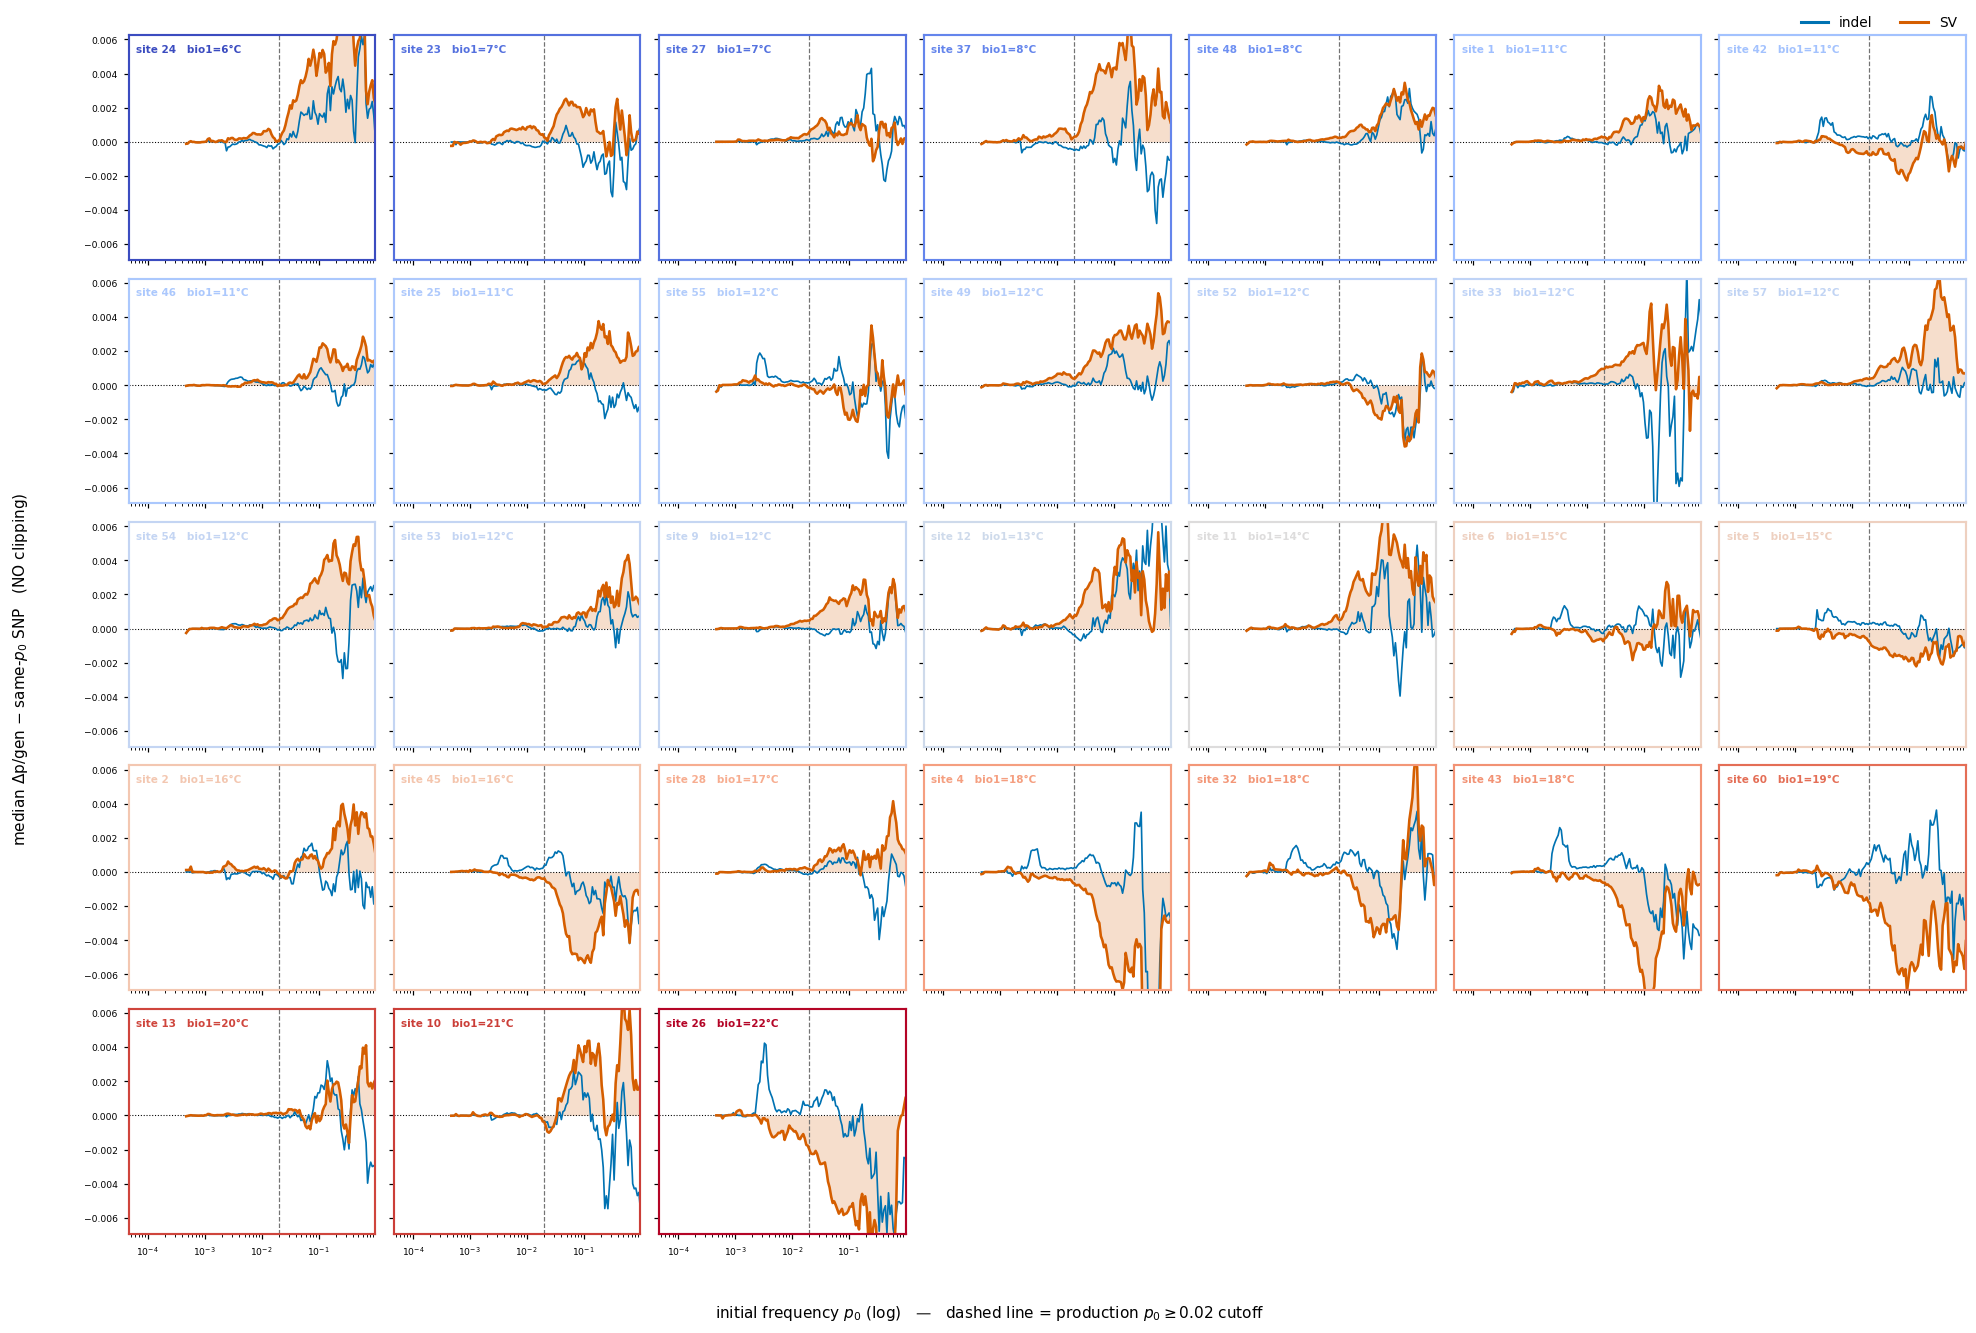

lin logx=True  ylim=(-0.0069199603633251176, 0.006243299448647122)


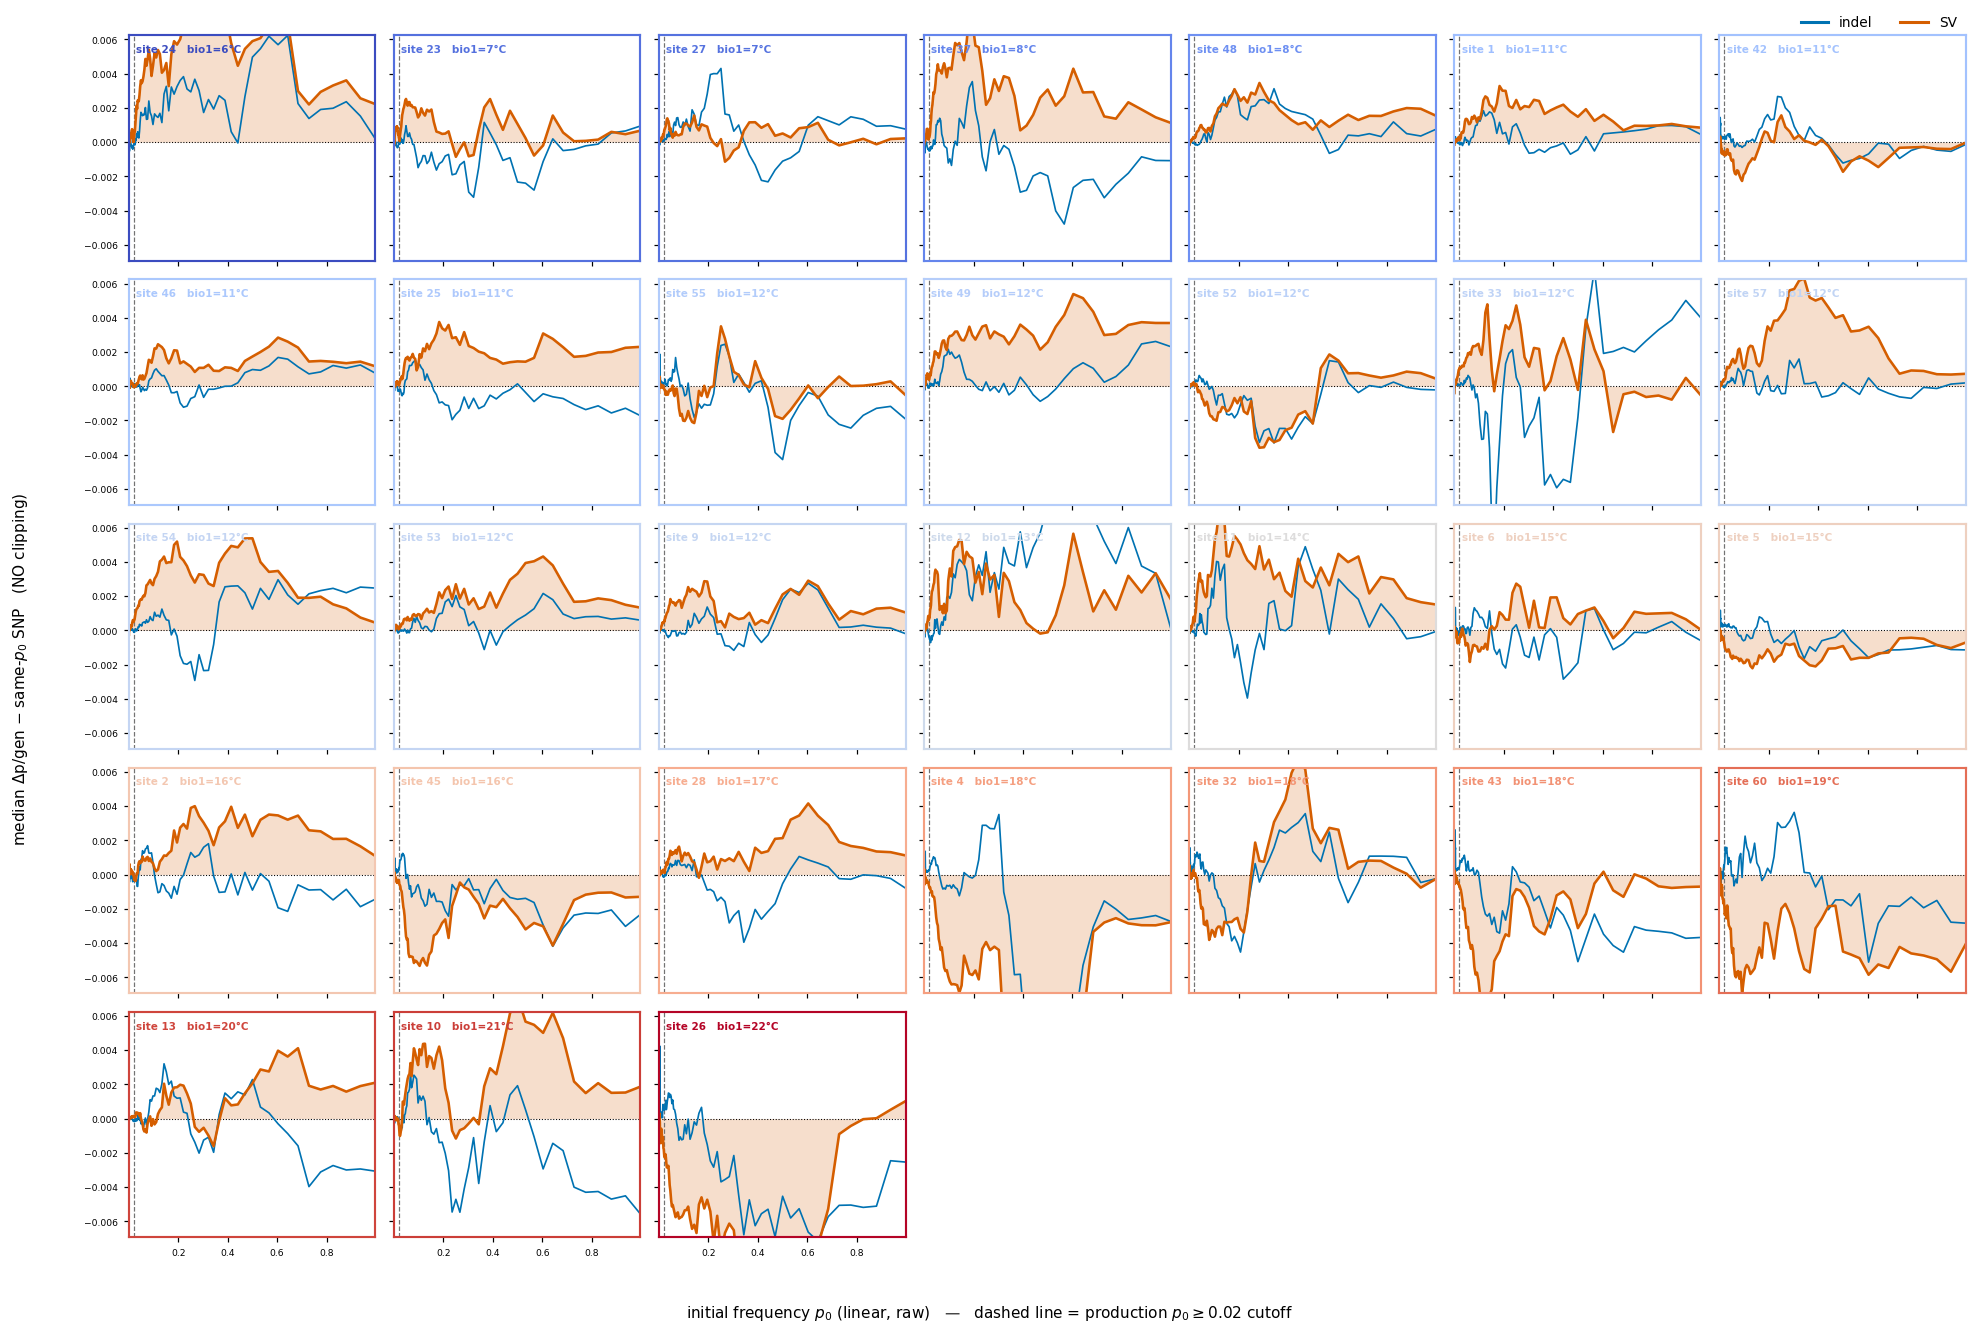

lin logx=False  ylim=(-0.0069199603633251176, 0.006243299448647122)


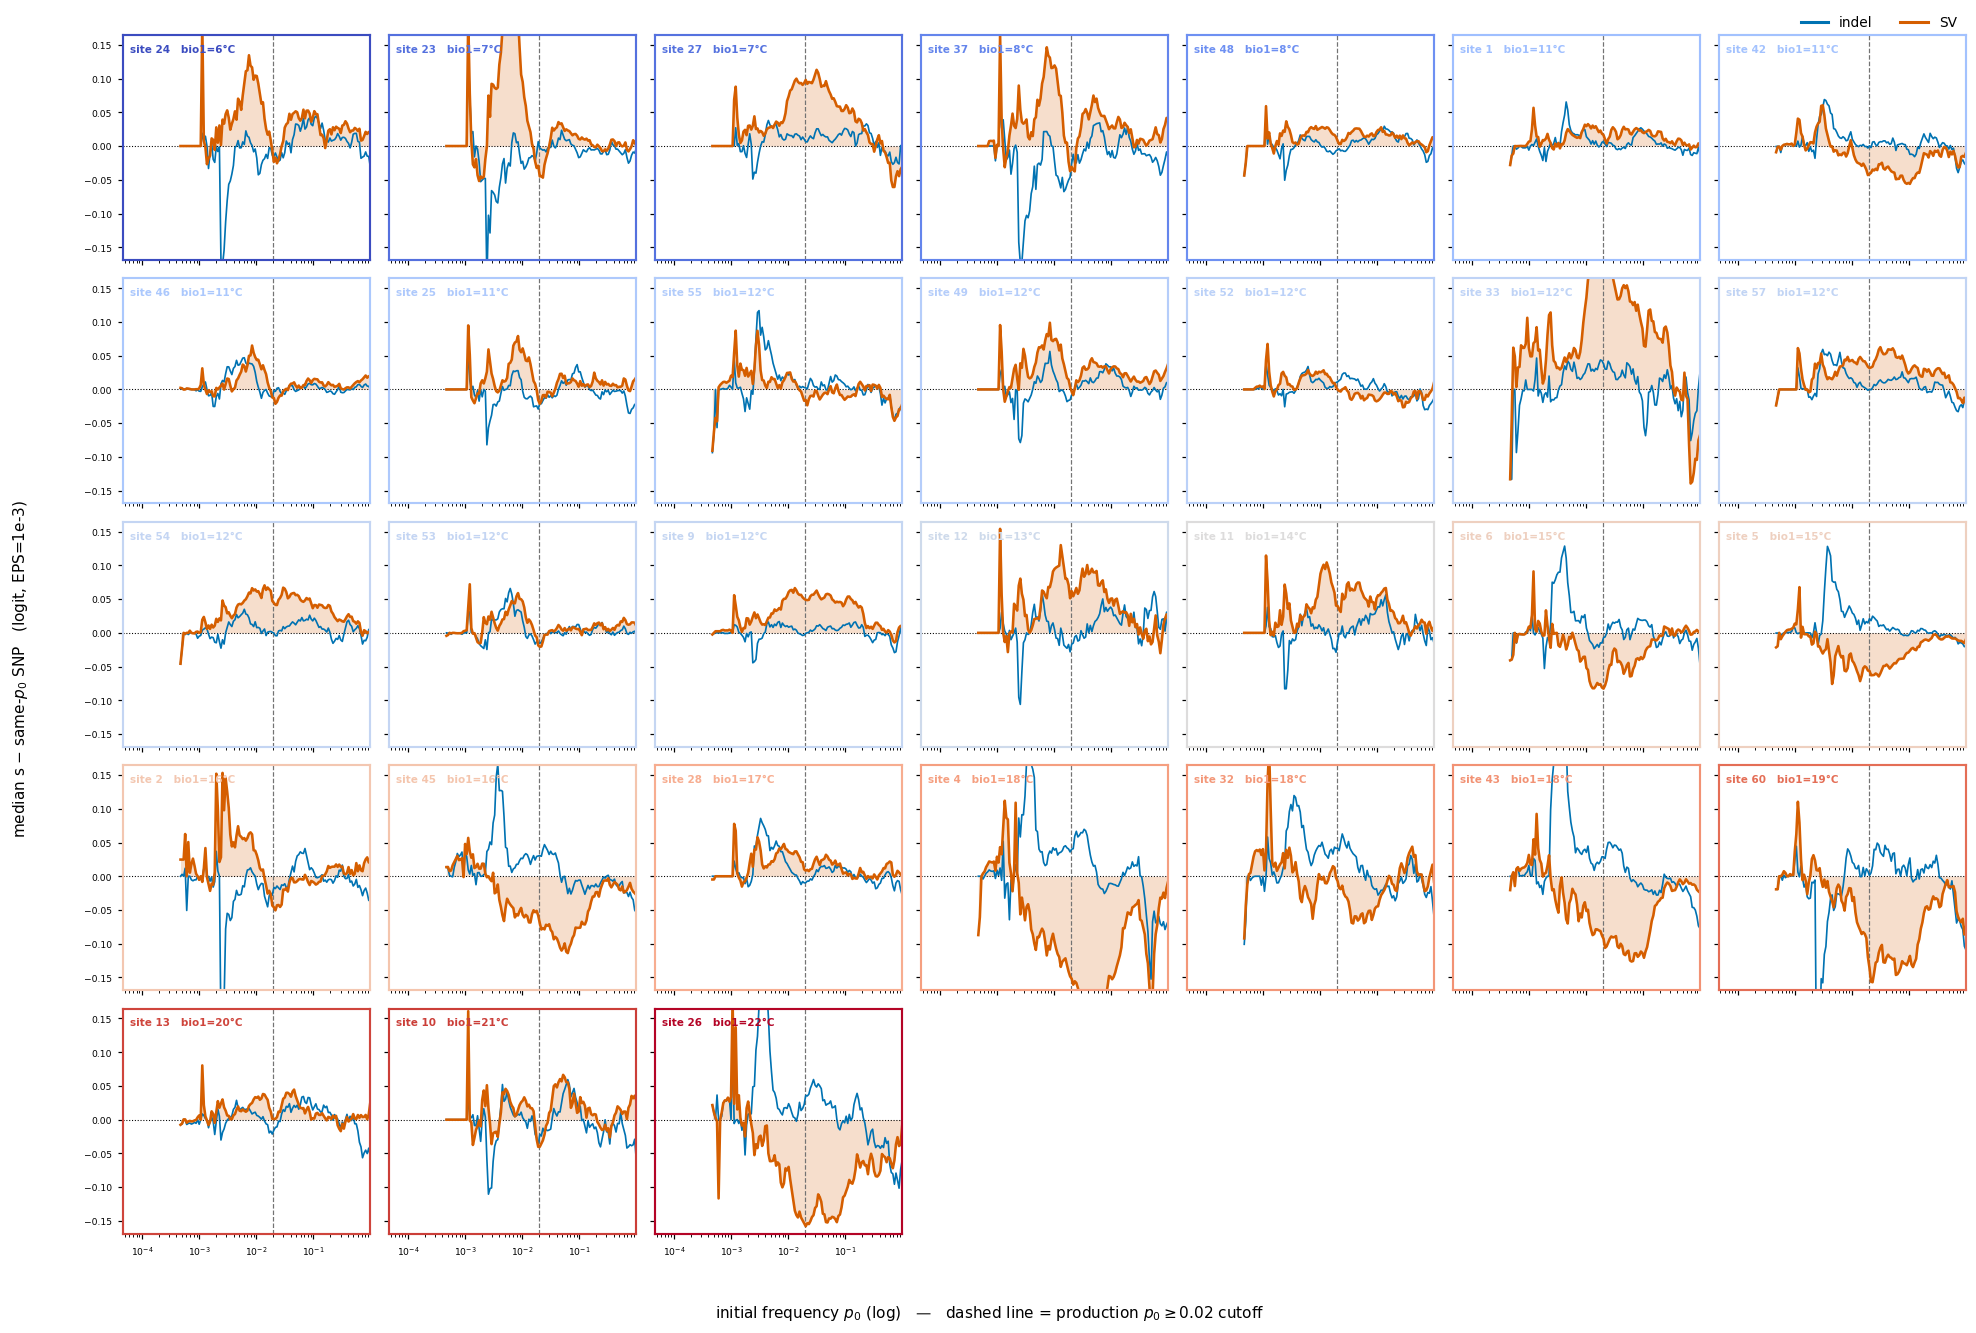

e3 logx=True  ylim=(-0.1686985726002604, 0.16454820665530862)


In [13]:

def matched_panel(tag, logx, ylab, fname):
    cv_sv = ncurves[tag]
    cv_in = {s: matched_curve(s, tag, "indel") for s in nsites}
    vis = np.concatenate([v[np.isfinite(v)] for d in (cv_sv, cv_in) for v in d.values()])
    q = np.nanpercentile(vis, [1, 99]); pad = 0.10 * (q[1] - q[0]); ylim = (q[0] - pad, q[1] + pad)
    ncol = 7; nrow = int(np.ceil(len(nsites) / ncol))
    norm = mpl.colors.Normalize(vmin=nmeta.bio1.min(), vmax=nmeta.bio1.max()); cmap = mpl.cm.coolwarm
    fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.4 * nrow), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax in axes[len(nsites):]:
        ax.axis("off")
    for i, s in enumerate(nsites):
        ax = axes[i]; ev, ei = cv_sv[s], cv_in[s]
        ax.axhline(0, color="k", lw=0.7, ls=":")
        ax.axvline(P0_BOUND, color="0.45", lw=0.8, ls="--")
        ax.fill_between(GRID, 0, np.nan_to_num(ev, nan=0.0), where=np.isfinite(ev),
                        color=COL["SV"], alpha=0.20, lw=0)
        ax.plot(GRID, ei, "-", color=COL["indel"], lw=1.1)
        ax.plot(GRID, ev, "-", color=COL["SV"], lw=1.7)
        c = cmap(norm(nmeta.bio1.iloc[i]))
        ax.annotate(f"site {int(s)}   bio1={nmeta.bio1.iloc[i]:.0f}°C", xy=(0.03, 0.96),
                    xycoords="axes fraction", va="top", ha="left", fontsize=6.8,
                    color=c, fontweight="bold")
        for sp in ax.spines.values():
            sp.set_color(c); sp.set_linewidth(1.4)
        if logx:
            ax.set_xscale("log")
        ax.set_xlim(GRID.min(), GRID.max()); ax.tick_params(labelsize=6)
    axes[0].set_ylim(*ylim)
    fig.supxlabel(f"initial frequency $p_0$ ({'log' if logx else 'linear, raw'})   —   dashed line = "
                  f"production $p_0\\geq0.02$ cutoff", y=0.005, fontsize=10)
    fig.supylabel(ylab, x=0.006, fontsize=10)
    fig.legend(handles=[Line2D([0], [0], color=COL[c], lw=2, label=c) for c in ["indel", "SV"]],
               loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.995, 1.004))
    fig.tight_layout(rect=[0.02, 0.02, 1, 0.99])
    fig.savefig(f"{PLOTS}/{fname}", dpi=130, bbox_inches="tight")
    plt.show()
    print(f"{tag} logx={logx}  ylim={ylim}")

matched_panel("lin", True, "median Δp/gen − same-$p_0$ SNP   (NO clipping)",
              "s_matchedwidth_linear_logx.png")
matched_panel("lin", False, "median Δp/gen − same-$p_0$ SNP   (NO clipping)",
              "s_matchedwidth_linear_linearx.png")
matched_panel("e3", True, "median s − same-$p_0$ SNP   (logit, EPS=1e-3)",
              "s_matchedwidth_logit_e3_logx.png")


## Takeaway

- **The climate gradient is not a filtering artefact.** Dropping MAC/call-rate/$p_0$-boundary and
  going from 4,946 → 226,468 SVs leaves ρ(bio1) ≈ −0.42…−0.61 and ρ(bio18) ≈ +0.73…+0.80, i.e.
  the same sign and comparable-or-stronger magnitude than filtered. The newly-admitted ultra-rare
  SVs carry the gradient at least as strongly as the retained ones (strongest ρ of any region).
- **It is not a bandwidth artefact.** Stable across a 40× matched-window range (51 → 2001), and
  separately stable when the production run's 5× SV-vs-baseline bandwidth mismatch is removed.
- **The panels are not usable as figures.** Unfiltered, 71.6% of SVs sit below $p_0=0.02$, so most
  of the curve is a local median over boundary-dominated ultra-rare variants and swings across the
  whole y-range. The production filters buy legibility and per-point reliability — read the
  climate scatter (§3) and sweep (§4) here, not the grids.
- **Filter-dependent caveat:** the whole-distribution median shift is ~null filtered but clearly
  **positive** unfiltered (SVs looking *less* purged than same-$p_0$ SNPs on average, 8–12/31 sites
  negative). The *gradient* is the robust claim; the *net level* is not.
- **The rare-tail "positive SV plateau" is NOT real (§5).** With no clipping at all and a baseline
  matched by $\log p_0$ width, the SV excess at $p_0\le2\times10^{-3}$ is **+0.00002** — exactly zero
  — versus **+0.01003** under the production logit clip. It was an artefact of (a) the EPS clip
  assigning every ultra-rare variant an identical fabricated starting logit and (b) a count-matched
  window letting the sparse SNP baseline borrow from distant frequencies. Rare SVs are **not** under
  positive selection.
- **The gradient survives even with no clipping anywhere (§5):** linear raw-frequency slope gives
  ρ(bio1) = −0.455 (p=0.010) and ρ(bio18) = **+0.748** (p<0.0001) in the production range, and
  −0.589 / +0.765 in the rare band. So it is not a logit/boundary artefact either.
- **It is a low-frequency effect (§1d).** On a linear $p_0$ axis essentially all structure sits below
  $p_0\approx0.1$; log-x visually oversold it as spanning the spectrum.
- **Known limit:** the matched-width baseline cannot go below $p_0\approx0.00047$ because only 252
  SNPs of the 25k subsample are that rare. That floor is a subsampling choice, not a data limit —
  the full 6.2M SNP set would push it ~250× lower.
- **Unaddressed:** hitchhiking (global-mode kMate AF is a founder-mixture projection) and the
  systematic insertion-polarity reference-bias caveat. Neither is a filter, window, or clipping
  question — both need independent SV allele frequencies. See `SV_TEMPORAL_PURGING_SUMMARY.md`.